# Correspondence Analysis (CA): periods, gender, country, occupation, field


## Documentation
* [Correspondence Analysis](https://en.wikipedia.org/wiki/Correspondence_analysis) (Wikipedia)
* [CA - Correspondence Analysis in R: Essentials](https://www.sthda.com/english/articles/31-principal-component-methods-in-r-practical-guide/113-ca-correspondence-analysis-in-r-essentials/)

* [Analyse factorielle des correspondances](https://fr.wikipedia.org/wiki/Analyse_factorielle_des_correspondances) (Wikipedia)
* [Analyse factorielle des correspondances](https://github.com/Sciences-historiques-numeriques/histoire_numerique_methodes/blob/main/statistiques_descriptives/analyse_factorielle_correspondances_manuels.ipynb)


### Add fanalysis library to pip environment

* Open a terminal and activate your data analysis environment:

    -> my_venvs_activate data_analysis
* Install the missing package in the active environment:

    -> pip install fanalysis
* Deactivate the environment when you have finished:

    -> my_venvs_deactivate


In [1]:
### Activate libraries that will be used in the notebook

import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

from fanalysis.ca import CA 

import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

We use in this notebook the data produced in the da3-1 chapter, i.e. a list of persons with birth year, gender, place of birth, world country of birth

In [4]:
csv_address='da_data/da4-AFC.csv'
df_p = pd.read_csv(csv_address)
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,France,1831,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1827,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.033056 48.139722),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1834,1826-1850


In [6]:
df_p = df_p.drop(['CNTR_ID', 'CNTR_NAME'], axis=1)

In [7]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20043 entries, 0 to 20042
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   uriPer           20043 non-null  object
 1   labelPer         20043 non-null  object
 2   birthYear        20043 non-null  int64 
 3   gender           20043 non-null  object
 4   labelPlace       20043 non-null  object
 5   geometry         20043 non-null  object
 6   uriPlace         20043 non-null  object
 7   periods          20043 non-null  object
 8   FID              20043 non-null  int64 
 9   REGION           20043 non-null  object
 10  NAME_ENGL        20043 non-null  object
 11  ISO3_CODE        20043 non-null  object
 12  coded_country    20043 non-null  object
 13  activityYear     20043 non-null  int64 
 14  periodsActivity  20043 non-null  object
dtypes: int64(3), object(12)
memory usage: 2.3+ MB


In [8]:
df_p=df_p.rename(columns={'uriPer': 'person_uri'})

In [9]:
df_p.head(1)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,France,FRA,France,1831,1826-1850


In [10]:
pd.set_option('display.max_columns', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns')

## AFC : Factor analysis

Cf. documentation at the top of the notebook

### Create bivariate summary and CA functions

To make the code more readable and keep it short, we will define several functions here that we will use below.



In [11]:
### ct_m : contingency table without totals in margins
def bivariate_stats(observed):

    ### Valeurs produites par la fonction de la librairie 'stats'
    statistic, p, dof, expected = stats.chi2_contingency(observed)

    print('Chi-square :', statistic.round(2), ', dof :',dof)
    print('p-value :', p.round(3))

    
    ## Phi-square coefficient = inertia
    phi_2=statistic/observed.sum().sum()
    print('Inertia (Phi-square): ', phi_2.round(3))

    ### Coéfficient de Cramer
    vc = stats.contingency.association(observed, method='cramer')
    print('Cramer: ', round(vc, 3))

    ## the returned expected contingency table can be stored in a variable and used in a function
    return expected





In [12]:
## test if expected contingency table follows the rules for validity of Chi-square test

def check_chi_square_test_validity(observed: pd.DataFrame) -> bool:
    """
    Validates a contingency table based on two criteria:
    1. No cell has a value less than 1.
    2. Not more than 20% of cells have values less than or equal to 5.
    
    Parameters:
    contingency_df (pd.DataFrame): The contingency table.
    
    Returns:
    bool: True if both conditions are met, False otherwise.
    """


    # Get expected contingency table
    statistic, p, dof, expected = stats.chi2_contingency(observed)
    
    # Condition 1: No cell has a value less than 1
    # min().min() gets the global minimum of the dataframe
    min_val = expected.min().min()
    condition_1 = min_val >= 1
    
    # Condition 2: Not more than 20% of cells have values <= 5
    total_cells = expected.size
    if total_cells == 0:
        return False # Or True, depending on how you define empty tables
        
    cells_le_5 = (expected <= 5).sum().sum()
    percent_le_5 = cells_le_5 / total_cells
    
    condition_2 = percent_le_5 <= 0.20

    # result : True or False
    result=condition_1 and condition_2
    
    return print(f"Table valid for Chi-square test: {result}")



In [13]:
### ct_m : contingency tables with totals in margins
def plot_chi2_residuals(observed, figsize=(9,3)):
    
    ### Get signed resitduals using statmodels (sm)

    # 1. Create the Table object directly from your data
    table = sm.stats.Table(observed)
    
    # 2. Get Adjusted Residuals instantly (no manual formula needed)
    adjusted_resids = table.standardized_resids
    adjusted_resids.round(1)
   

    fig, ax = plt.subplots(figsize=figsize)         
    
    # Create heatmap
    sns.heatmap(
        adjusted_resids.round(1), 
        annot=True,            # Use boolean True to annotate with data values
        cmap="coolwarm", 
        linewidths=.5, 
        ax=ax,
        cbar_kws={'label': 'Residuals'}
    )
    # 3. Fix Label Rotation (Safe Method)
    # This rotates existing ticks without risking a count mismatch
    ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')
    ax.set_title("Adjusted Residual", fontsize=12)
    
    # ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
    plt.tight_layout()
    plt.show()

In [14]:
def print_eigenvalue(afc):

    eig = pd.DataFrame(afc.eig_)

    r1 = round(eig.iloc[0], 3)
    r2 = round(eig.iloc[2], 2)
    s=list(range(1,len(r1)+1))
    r1.index=s
    r2.index=s

    # https://www.statology.org/pandas-subplots/
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,3))

    ax1 = r1.plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
    ax2 = r2.plot(kind='bar', ax=axes[1], title="Frequence cumulative de l'eigenvalue ")


    ax1.bar_label(ax1.containers[0])
    ax2.bar_label(ax2.containers[0])


    # Met les valeurs xticks en vertical
    fig.autofmt_xdate(rotation=0)
    plt.show()

In [15]:
def contributions_colonnes(afc):
    
    # Informations sur les contributions des colonnes
    df = afc.col_topandas()[['col_contrib_dim1',
                            'col_contrib_dim2',
                            'col_contrib_dim3']]

    r1 = df.iloc[:,0]
    r2 = df.iloc[:,1]
    r3 = df.iloc[:,2]

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,6), )

    r1.sort_values().plot(kind='barh', ax=axes[0,0], title='Dim.1')
    r2.sort_values().plot(kind='barh', ax=axes[0,1], title='Dim.2')
    r3.sort_values().plot(kind='barh', ax=axes[0,2], title='Dim.3')

    ### Rows
    df = afc.row_topandas()[['row_contrib_dim1',
                            'row_contrib_dim2',
                            'row_contrib_dim3']]
    r1 = df.iloc[:,0]
    r2 = df.iloc[:,1]
    r3 = df.iloc[:,2]

    r1.sort_values().plot(kind='barh', ax=axes[1,0], title='Dim.1')
    r2.sort_values().plot(kind='barh', ax=axes[1,1], title='Dim.2')
    r3.sort_values().plot(kind='barh', ax=axes[1,2], title='Dim.3')

    plt.tight_layout()
    plt.show()


In [16]:
def code_gender(gender: str):
    if gender == 'female':
        output='f'
    else:
        output='m'
    return output    

### Analyse countries and activity periods

In [17]:
### Inspect coded countries
print(df_p.groupby(by='coded_country').size().sort_values(ascending=False))

coded_country
Germany                      3158
United States Can.           2769
Russian Federation           2458
Italy                        1128
United Kingdom               1120
France                       1115
Czechia                      1005
Poland                        990
Austria Hungary               875
Baltic States Fin. Belar.     866
Ukraine                       851
Central Europe                799
Belgium Netherl.              480
Japan                         459
Spain Port.                   381
Scandinavia                   377
China                         315
Switzerland                   314
India                         306
South America                 277
dtype: int64


In [18]:
### Inspect activity periods
print(df_p.groupby(by='periodsActivity').size().sort_values(ascending=False))

periodsActivity
1976-2000    6675
1951-1975    4695
2001-2025    3175
1926-1950    2215
1901-1925    1416
1876-1900     913
1851-1875     559
1826-1850     395
dtype: int64


In [19]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_country=pd.crosstab(df_p.periodsActivity, df_p.coded_country, margins=True)

## display all columns
pd.set_option('display.max_columns', None)

per_vs_country.iloc[2:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
periodsActivity,,,,,,,,,,,,,,,,,,,,,
1876-1900,47,22,30,25,0,53,110,180,3,61,4,46,51,26,5,17,27,16,103,87,913
1901-1925,67,35,33,52,1,60,144,277,3,90,17,66,107,41,5,31,32,45,106,204,1416
1926-1950,123,55,69,74,14,92,144,387,15,88,40,116,259,68,13,35,43,111,134,335,2215
1951-1975,219,179,107,178,100,184,199,650,63,165,143,195,675,69,51,42,64,260,276,876,4695
1976-2000,257,392,117,307,124,360,262,868,162,314,168,386,1054,88,112,109,73,338,276,908,6675
2001-2025,132,159,91,140,73,220,114,598,56,317,86,127,281,45,87,138,47,69,101,294,3175
All,875,866,480,799,315,1005,1115,3158,306,1128,459,990,2458,377,277,381,314,851,1120,2769,20043


In [20]:
observed = per_vs_country.iloc[2:-1, :-1 ]
observed

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,,,,,,
1876-1900,47,22,30,25,0,53,110,180,3,61,4,46,51,26,5,17,27,16,103,87
1901-1925,67,35,33,52,1,60,144,277,3,90,17,66,107,41,5,31,32,45,106,204
1926-1950,123,55,69,74,14,92,144,387,15,88,40,116,259,68,13,35,43,111,134,335
1951-1975,219,179,107,178,100,184,199,650,63,165,143,195,675,69,51,42,64,260,276,876
1976-2000,257,392,117,307,124,360,262,868,162,314,168,386,1054,88,112,109,73,338,276,908
2001-2025,132,159,91,140,73,220,114,598,56,317,86,127,281,45,87,138,47,69,101,294


In [21]:
check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [22]:
expected=bivariate_stats(observed)

Chi-square : 1616.02 , dof : 95
p-value : 0.0
Inertia (Phi-square):  0.085
Cramer:  0.13


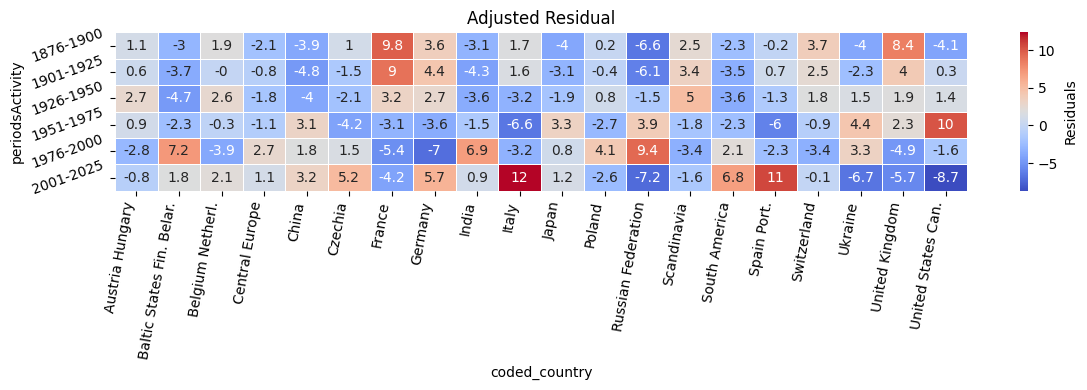

In [23]:
pp = plot_chi2_residuals(observed, figsize=(12, 4))

### Analyse factorielle des correspondances (AFC)

In [24]:
observed

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,,,,,,
1876-1900,47,22,30,25,0,53,110,180,3,61,4,46,51,26,5,17,27,16,103,87
1901-1925,67,35,33,52,1,60,144,277,3,90,17,66,107,41,5,31,32,45,106,204
1926-1950,123,55,69,74,14,92,144,387,15,88,40,116,259,68,13,35,43,111,134,335
1951-1975,219,179,107,178,100,184,199,650,63,165,143,195,675,69,51,42,64,260,276,876
1976-2000,257,392,117,307,124,360,262,868,162,314,168,386,1054,88,112,109,73,338,276,908
2001-2025,132,159,91,140,73,220,114,598,56,317,86,127,281,45,87,138,47,69,101,294


In [25]:
# Initialise the CA object, then fit (=calculate)
afc = CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1876-...iodsActivity')
,col_labels,Index(['Austr...oded_country')
,stats,True


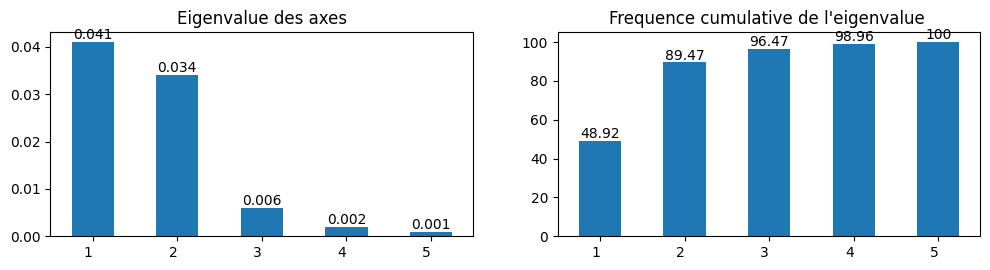

In [26]:
### Inertia (Phi-square):  0.085
print_eigenvalue(afc)

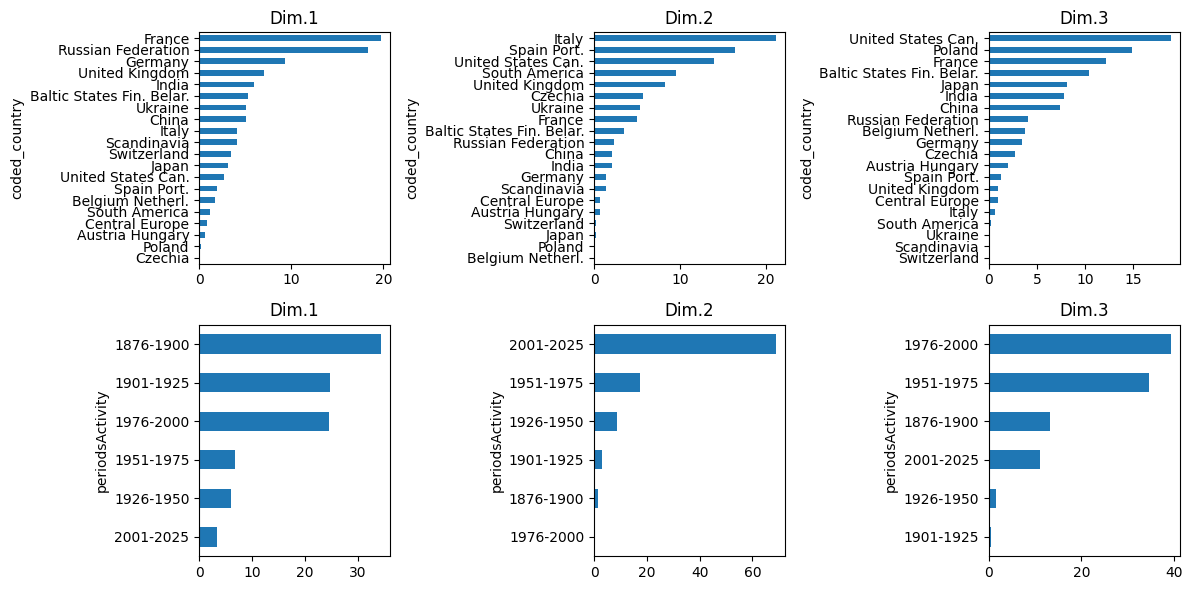

In [27]:
contributions_colonnes(afc)

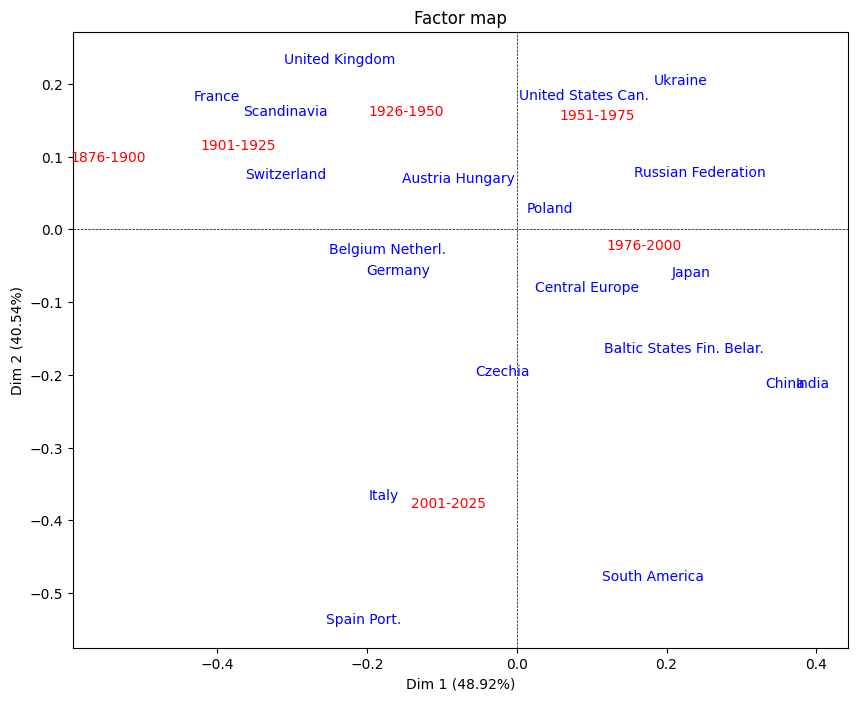

In [28]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(10,8))

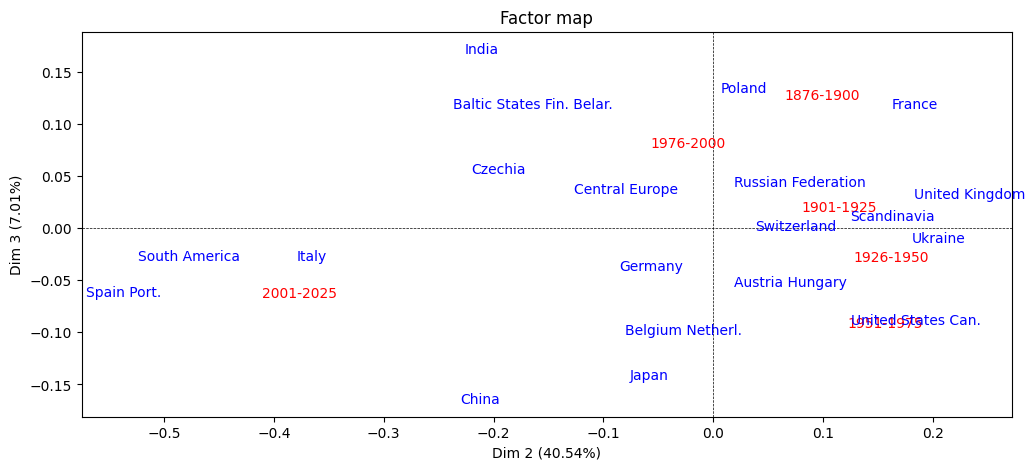

In [29]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(12,5))

On the third dimension we can notably observe the situation of Poland. Compare with Italy and France 

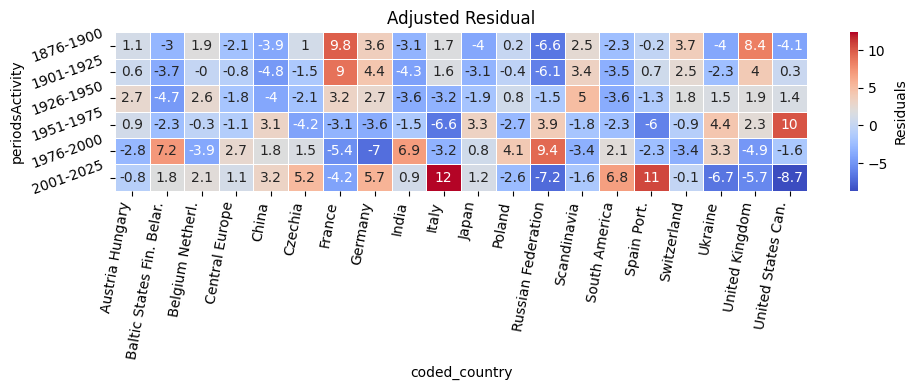

In [30]:
## Use the adjusted residual to test the interpretation
pp = plot_chi2_residuals(observed, figsize=(10, 4))

## Gender and period vs country

In [31]:
### Apply function and create new column
df_p['per_gender']= df_p.apply(lambda x: x.periodsActivity +'_'+ code_gender(x.gender), axis=1)

In [32]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,per_gender
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,France,FRA,France,1831,1826-1850,1826-1850_m
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,Germany,DEU,Germany,1827,1826-1850,1826-1850_m


In [33]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
perGen_vs_country=pd.crosstab(df_p.per_gender, df_p.coded_country, margins=True)

perGen_vs_country

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
per_gender,,,,,,,,,,,,,,,,,,,,,
1826-1850_f,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,3
1826-1850_m,10,15,14,12,1,19,53,74,1,45,0,21,13,17,1,2,13,5,59,17,392
1851-1875_f,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,4,3,8
1851-1875_m,20,9,19,11,2,17,89,124,3,47,1,33,18,23,3,7,15,7,58,45,551
1876-1900_f,0,0,1,0,0,1,0,0,1,0,0,0,2,0,0,0,0,0,4,6,15
1876-1900_m,47,22,29,25,0,52,110,180,2,61,4,46,49,26,5,17,27,16,99,81,898
1901-1925_f,4,0,0,2,0,1,1,3,0,0,0,2,4,4,0,0,0,2,11,29,63
1901-1925_m,63,35,33,50,1,59,143,274,3,90,17,64,103,37,5,31,32,43,95,175,1353
1926-1950_f,16,1,5,4,0,5,17,18,1,10,0,6,18,3,2,3,0,5,12,48,174


In [34]:
observed = perGen_vs_country.iloc[:-1, :-1 ]

In [35]:
check_chi_square_test_validity(observed)

Table valid for Chi-square test: False


In [36]:
observed = perGen_vs_country.iloc[8:-1, :-1 ]

In [37]:
check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [38]:
expected=bivariate_stats(observed)

Chi-square : 1336.27 , dof : 133
p-value : 0.0
Inertia (Phi-square):  0.08
Cramer:  0.107


### AFC

In [39]:
afc = CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1926-...='per_gender')
,col_labels,Index(['Austr...oded_country')
,stats,True


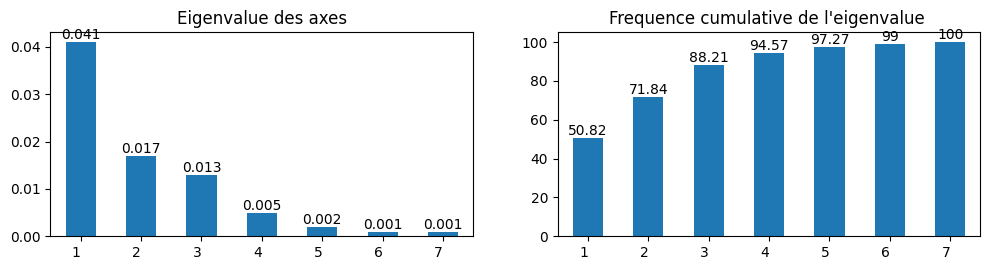

In [40]:
# Represent dimension 1 and 2
print_eigenvalue(afc)

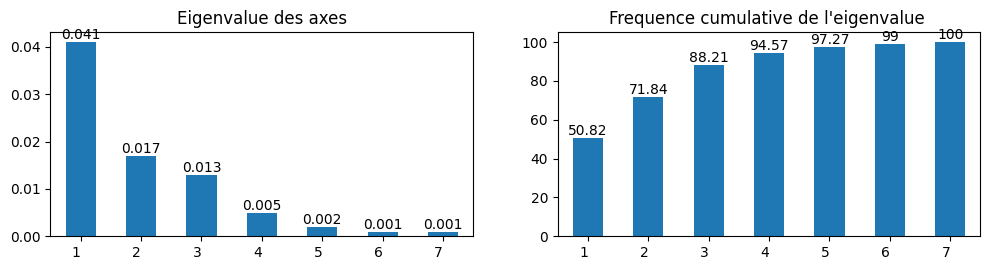

In [41]:
### Inertia (Phi-square - Eigenvalue):  0.108
print_eigenvalue(afc)

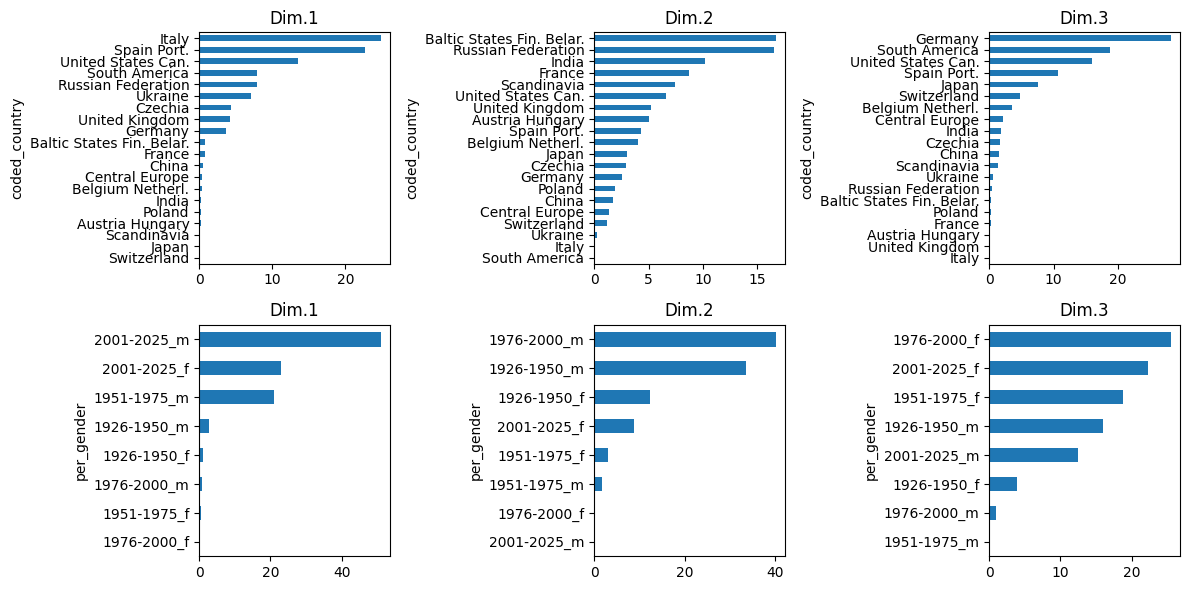

In [42]:
contributions_colonnes(afc)

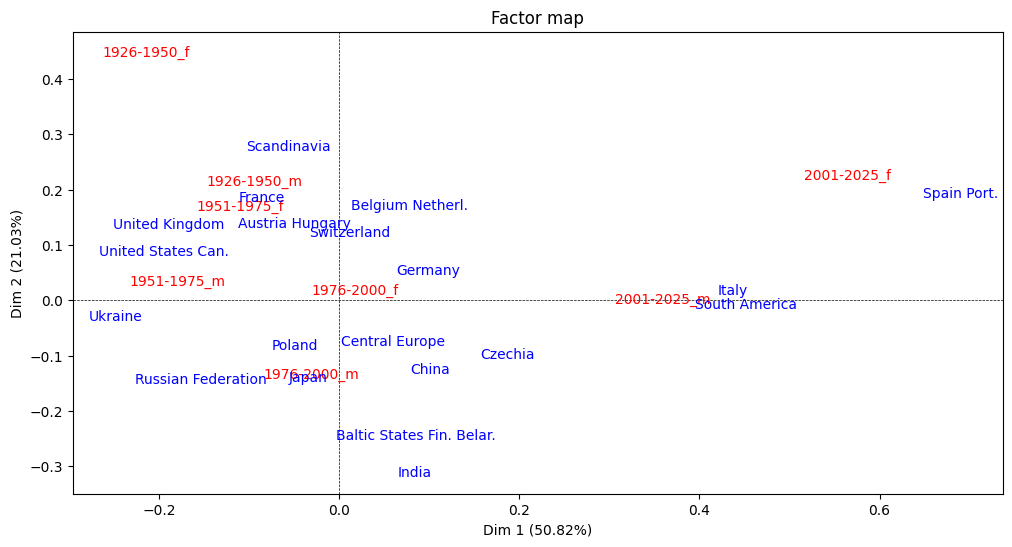

In [43]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(12,6))

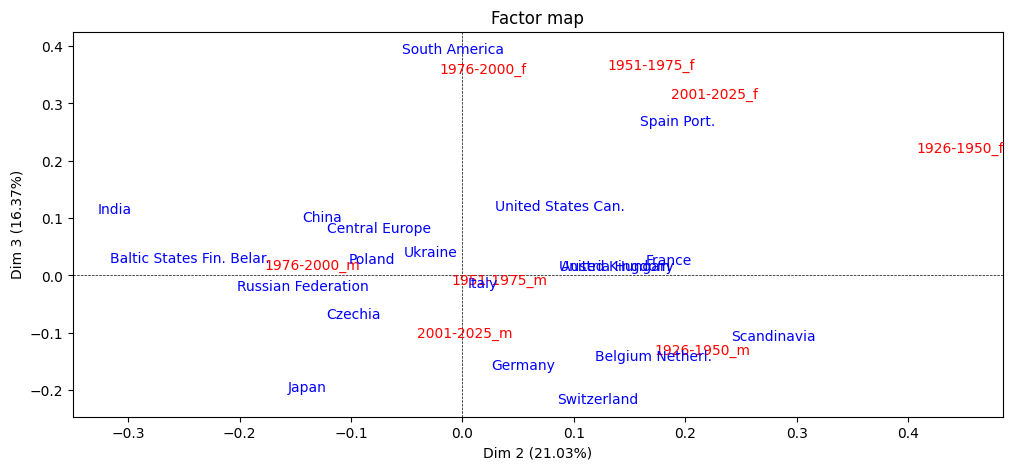

In [44]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(12,5))

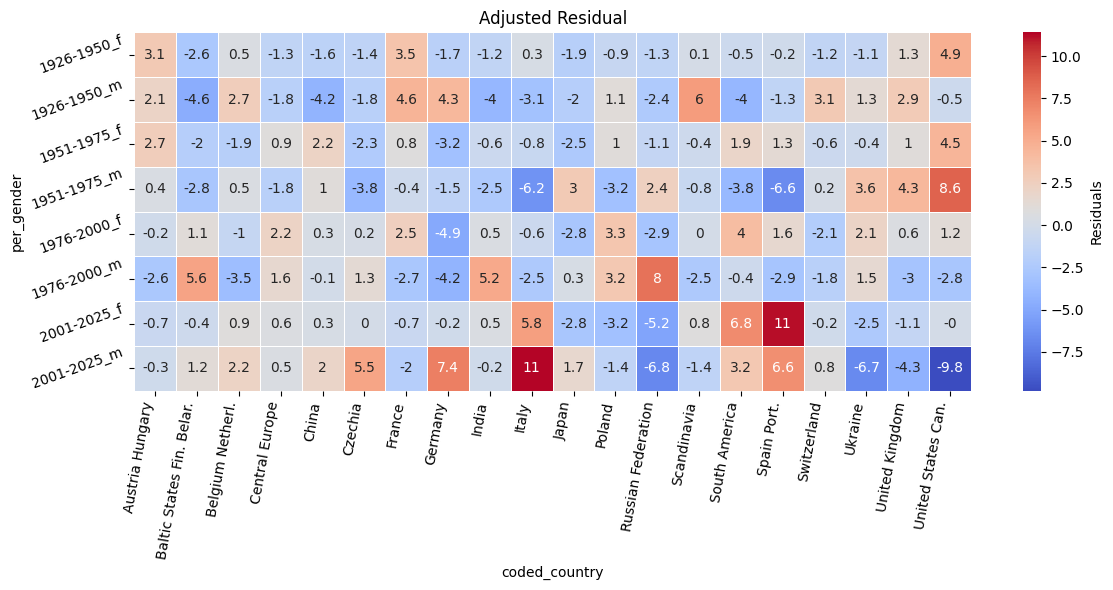

In [45]:
pp = plot_chi2_residuals(observed, figsize=(12, 6))

In [46]:
### do not forget the number:
# proportionally more women but in mumber more men
observed


coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.
per_gender,,,,,,,,,,,,,,,,,,,,
1926-1950_f,16,1,5,4,0,5,17,18,1,10,0,6,18,3,2,3,0,5,12,48
1926-1950_m,107,54,64,70,14,87,127,369,14,78,40,110,241,65,11,32,43,106,122,287
1951-1975_f,23,7,2,16,11,7,16,26,4,13,1,19,35,4,9,9,3,13,18,72
1951-1975_m,196,172,105,162,89,177,183,624,59,152,142,176,640,65,42,33,61,247,258,804
1976-2000_f,18,25,7,27,9,23,29,29,9,20,2,36,38,7,17,13,1,29,23,71
1976-2000_m,239,367,110,280,115,337,233,839,153,294,166,350,1016,81,95,96,72,309,253,837
2001-2025_f,18,21,14,23,10,25,18,71,10,54,3,9,27,10,26,43,6,11,18,70
2001-2025_m,114,138,77,117,63,195,96,527,46,263,83,118,254,35,61,95,41,58,83,224


## Occupation and field as additional qualitative variables

In [47]:
csv_address='da_data/da4-persons-features.csv'
# Explicitly tell pandas which strings to treat as NA (exclude 'NA' from the list)
# By default, pandas treats 'NA', 'N/A', 'NaN', etc. as missing values.
# If you want to override this by specifying a custom list that does NOT include 'NA'.
## df_pfeat = pd.read_csv(csv_address, na_values=['', 'N/A', 'NULL', 'None'])
df_pfeat = pd.read_csv(csv_address)
df_pfeat.head()

,pk_person_features,person_uri,occupation_main,occupation_sec1,occupation_sec2,field_main,field_sec1,field_sec2,fk_person,notes
0,1,http://www.wikidata.org/entity/Q1000193,astronomer,NaN,NaN,NaN,NaN,NaN,1,NaN
1,2,http://www.wikidata.org/entity/Q1000934,physicist,university-teacher,nuclear-physicist,NaN,NaN,NaN,2,NaN
2,3,http://www.wikidata.org/entity/Q100153910,physicist,university-teacher,NaN,NaN,NaN,NaN,3,NaN
3,4,http://www.wikidata.org/entity/Q100155322,physicist,NaN,NaN,fluid-mechanics,nonlinear-dynamics,NaN,4,NaN
4,5,http://www.wikidata.org/entity/Q100157315,physicist,university-teacher,NaN,NaN,NaN,NaN,5,NaN


In [48]:
### Observe the 
df_pfeat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32986 entries, 0 to 32985
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pk_person_features  32986 non-null  int64  
 1   person_uri          32986 non-null  object 
 2   occupation_main     32150 non-null  object 
 3   occupation_sec1     18263 non-null  object 
 4   occupation_sec2     7903 non-null   object 
 5   field_main          10807 non-null  object 
 6   field_sec1          5439 non-null   object 
 7   field_sec2          3388 non-null   object 
 8   fk_person           32986 non-null  int64  
 9   notes               0 non-null      float64
dtypes: float64(1), int64(2), object(7)
memory usage: 2.5+ MB


In [49]:
df_p = pd.merge(df_p,df_pfeat, on='person_uri', how='left')

In [50]:
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20043 entries, 0 to 20042
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   person_uri          20043 non-null  object 
 1   labelPer            20043 non-null  object 
 2   birthYear           20043 non-null  int64  
 3   gender              20043 non-null  object 
 4   labelPlace          20043 non-null  object 
 5   geometry            20043 non-null  object 
 6   uriPlace            20043 non-null  object 
 7   periods             20043 non-null  object 
 8   FID                 20043 non-null  int64  
 9   REGION              20043 non-null  object 
 10  NAME_ENGL           20043 non-null  object 
 11  ISO3_CODE           20043 non-null  object 
 12  coded_country       20043 non-null  object 
 13  activityYear        20043 non-null  int64  
 14  periodsActivity     20043 non-null  object 
 15  per_gender          20043 non-null  object 
 16  pk_p

In [51]:
df_p.iloc[50:54]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,per_gender,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,field_main,field_sec1,field_sec2,fk_person,notes
50,http://www.wikidata.org/entity/Q1676820,Jabbo Oltmanns,1783,male,Wittmund,POINT (7.780833 53.574722),http://www.wikidata.org/entity/Q509353,1781-1790,22,Western Europe,Germany,DEU,Germany,1828,1826-1850,1826-1850_m,11738,astronomer,university-teacher,mathematician,NaN,NaN,NaN,11738,NaN
51,http://www.wikidata.org/entity/Q522467,Carlo Luigi Giuseppe Bertero,1789,male,Santa Vittoria d'Alba,POINT (7.933333 44.7),http://www.wikidata.org/entity/Q20485,1781-1790,19,Southern Europe,Italy,ITA,Italy,1834,1826-1850,1826-1850_m,22371,physicist,botanist,botanical-collector,botany,NaN,NaN,22371,NaN
52,http://www.wikidata.org/entity/Q46923532,Pietro Petrini,1785,male,Pistoia,POINT (10.916667 43.933333),http://www.wikidata.org/entity/Q13376,1781-1790,19,Southern Europe,Italy,ITA,Italy,1830,1826-1850,1826-1850_m,21176,physicist,university-teacher,NaN,NaN,NaN,NaN,21176,NaN
53,http://www.wikidata.org/entity/Q8814,Augustin-Louis Cauchy,1789,male,Paris,POINT (2.352222 48.856667),http://www.wikidata.org/entity/Q90,1781-1790,22,Western Europe,France,FRA,France,1834,1826-1850,1826-1850_m,29755,physicist,university-teacher,mathematician,mathematics,mathematical-physics,mechanics,29755,NaN


In [52]:
### missing values are excluded by default
# To keep them add parameter , dropna=False
df_p.groupby(by='occupation_main', dropna=False).size()


occupation_main
astronomer     4114
physicist     15409
NaN             520
dtype: int64

## Country vs main occupation

In [53]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
occupation_vs_country=pd.crosstab(df_p.occupation_main, df_p.coded_country, margins=True)

occupation_vs_country

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
occupation_main,,,,,,,,,,,,,,,,,,,,,
astronomer,164,126,154,136,42,218,298,453,47,234,141,180,293,109,71,93,54,123,373,805,4114
physicist,695,696,319,656,270,725,802,2646,255,876,315,794,2013,264,202,284,255,700,725,1917,15409
All,859,822,473,792,312,943,1100,3099,302,1110,456,974,2306,373,273,377,309,823,1098,2722,19523


In [54]:
observed = occupation_vs_country.iloc[:-1, :-1 ]

In [55]:
check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [56]:
expected=bivariate_stats(observed)

Chi-square : 581.93 , dof : 19
p-value : 0.0
Inertia (Phi-square):  0.03
Cramer:  0.173


### AFC

In [57]:
afc = CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['astro...upation_main')
,col_labels,Index(['Austr...oded_country')
,stats,True


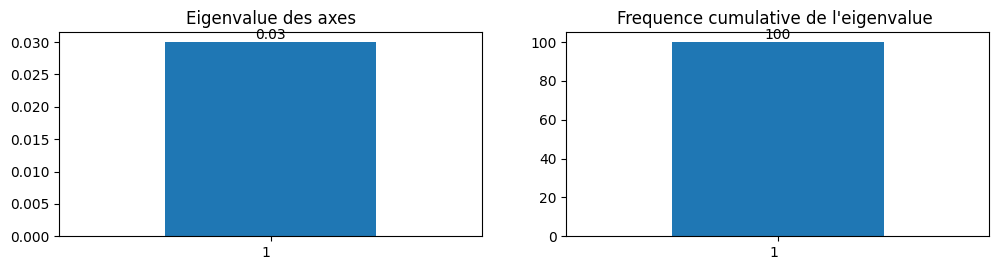

In [62]:
# One only dimension represents the whole inertia/variance
print_eigenvalue(afc)

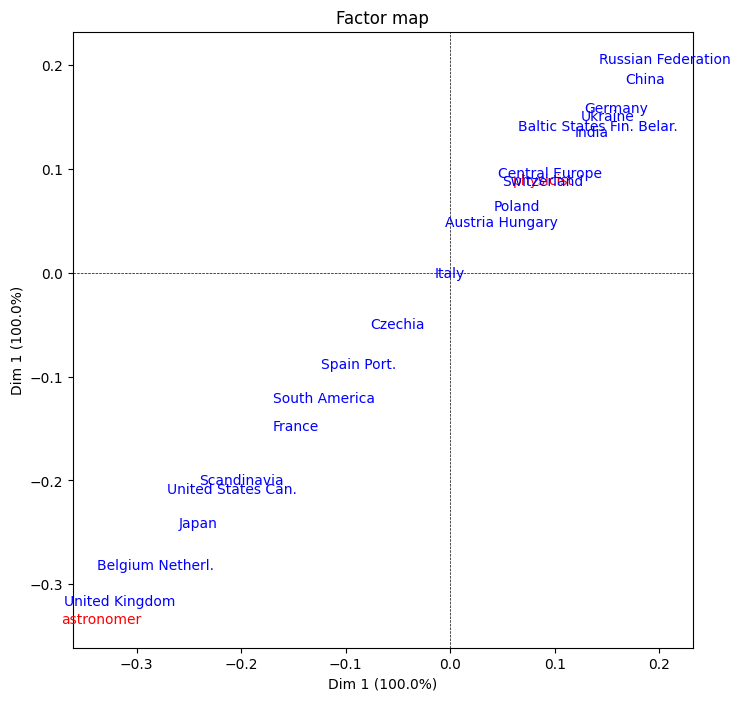

In [64]:
### Represent dimension 1: this would normally be represented along the horizontal axis.
# However, the Python library does not anticipate this possibility.
# We therefore represent it on the diagonal, 
# and can observe attraction and repulsion among categories.
afc.mapping(num_x_axis=1,num_y_axis=1,figsize=(8,8))

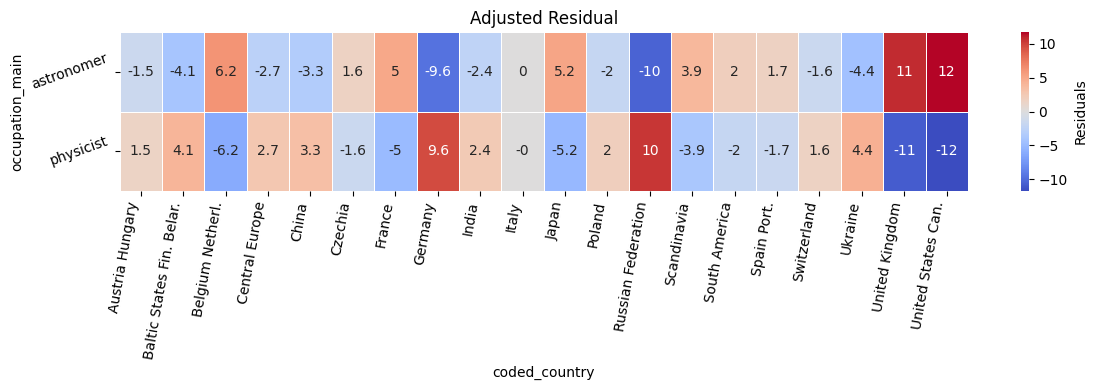

In [67]:
pp = plot_chi2_residuals(observed, figsize=(12, 4))

## Period vs main occupation

In [65]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
occupation_vs_activityPeriod=pd.crosstab(df_p.occupation_main, df_p.periodsActivity, margins=True)
occupation_vs_activityPeriod

periodsActivity,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025,All
occupation_main,,,,,,,,,
astronomer,187,260,357,518,528,739,913,612,4114
physicist,203,284,512,855,1633,3867,5577,2478,15409
All,390,544,869,1373,2161,4606,6490,3090,19523


In [66]:
observed = occupation_vs_activityPeriod.iloc[:-1, :-1 ]

In [67]:
check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [68]:
expected=bivariate_stats(observed)

Chi-square : 1120.24 , dof : 7
p-value : 0.0
Inertia (Phi-square):  0.057
Cramer:  0.24


### AFC

In [69]:
afc = CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['astro...upation_main')
,col_labels,Index(['1826-...iodsActivity')
,stats,True


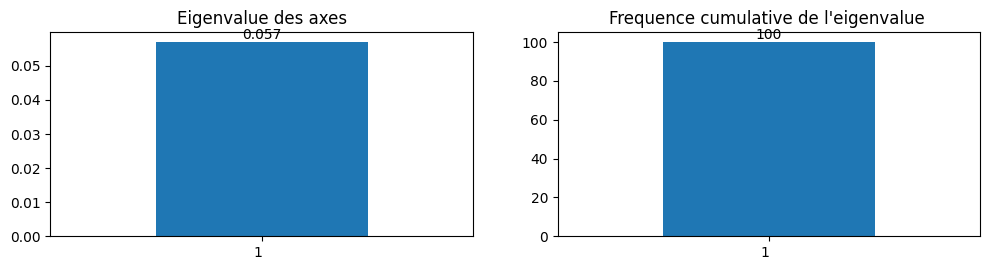

In [70]:
# Represent dimension 1 and 2
print_eigenvalue(afc)

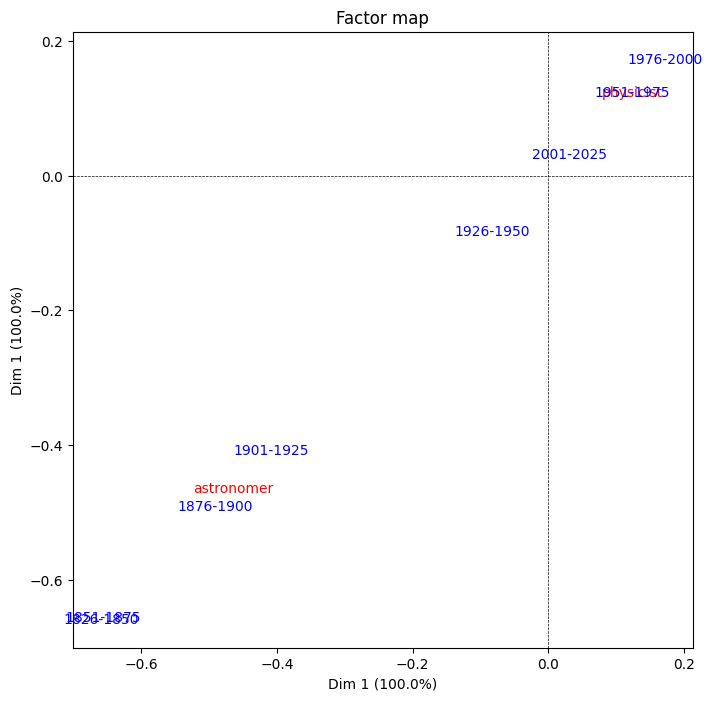

In [71]:
### Represent dimension 1: this would normally be represented along the horizontal axis.
# However, the Python library does not anticipate this possibility.
# We therefore represent it on the diagonal, 
# and can observe attraction and repulsion among categories.
afc.mapping(num_x_axis=1,num_y_axis=1,figsize=(8,8))

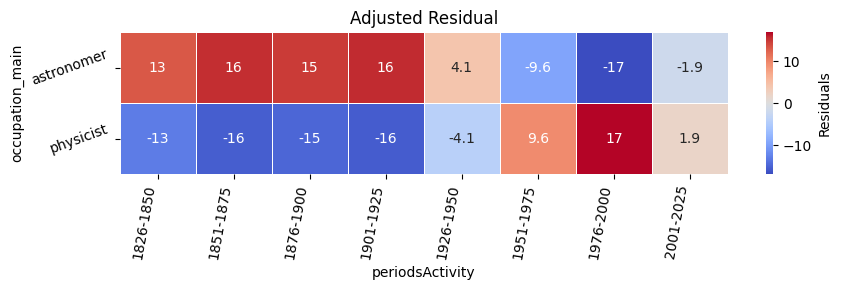

In [131]:
pp = plot_chi2_residuals(observed, figsize=(9, 3))

## Period and country vs main occupation

In [72]:
### Apply function and create new column
df_p['per_occupation']= df_p.apply(lambda x: np.nan if pd.isna(x.occupation_main) \
                              else x.periodsActivity +'_'+ x.occupation_main, axis=1)

In [73]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,per_gender,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,field_main,field_sec1,field_sec2,fk_person,notes,per_occupation
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,France,FRA,France,1831,1826-1850,1826-1850_m,27877,astronomer,mathematician,geographer,NaN,NaN,NaN,27877,NaN,1826-1850_astronomer
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,Germany,DEU,Germany,1827,1826-1850,1826-1850_m,26130,astronomer,military-personnel,NaN,astronomy,NaN,NaN,26130,NaN,1826-1850_astronomer


In [74]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_occ_vs_country=pd.crosstab(df_p.per_occupation, df_p.coded_country, margins=True)
per_occ_vs_country

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
per_occupation,,,,,,,,,,,,,,,,,,,,,
1826-1850_astronomer,6,10,7,7,1,4,15,32,1,18,0,12,9,12,0,1,1,1,38,12,187
1826-1850_physicist,4,4,6,5,0,14,38,42,0,27,0,9,3,5,1,1,12,3,24,5,203
1851-1875_astronomer,6,6,6,2,2,6,39,42,3,24,0,15,10,12,2,3,5,4,39,34,260
1851-1875_physicist,13,3,13,9,0,9,48,76,0,23,1,17,7,11,1,4,10,3,23,13,284
1876-1900_astronomer,15,9,11,9,0,18,47,50,3,22,1,15,14,11,3,11,6,5,55,52,357
1876-1900_physicist,30,11,19,15,0,26,60,118,0,38,3,29,32,14,2,6,21,10,45,33,512
1901-1925_astronomer,21,15,12,19,1,18,56,79,3,23,6,23,33,16,2,20,10,13,45,103,518
1901-1925_physicist,45,18,21,33,0,36,84,191,0,65,11,39,65,24,3,11,21,31,61,96,855
1926-1950_astronomer,19,14,25,15,3,35,36,64,3,27,12,21,57,16,8,11,6,26,34,96,528


In [75]:
observed = per_occ_vs_country.iloc[:-1, :-1 ]

In [76]:
check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [77]:
expected=bivariate_stats(observed)

Chi-square : 3001.19 , dof : 285
p-value : 0.0
Inertia (Phi-square):  0.154
Cramer:  0.101


### AFC

In [78]:
afc = CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1826-...r_occupation')
,col_labels,Index(['Austr...oded_country')
,stats,True


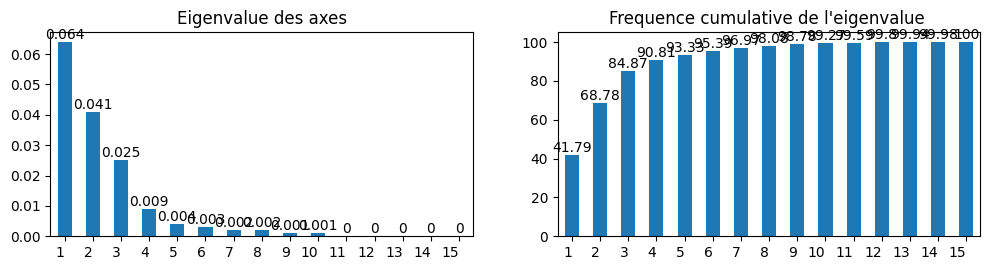

In [79]:
### Inertia (Phi-square - Eigenvalue):  0.083
print_eigenvalue(afc)

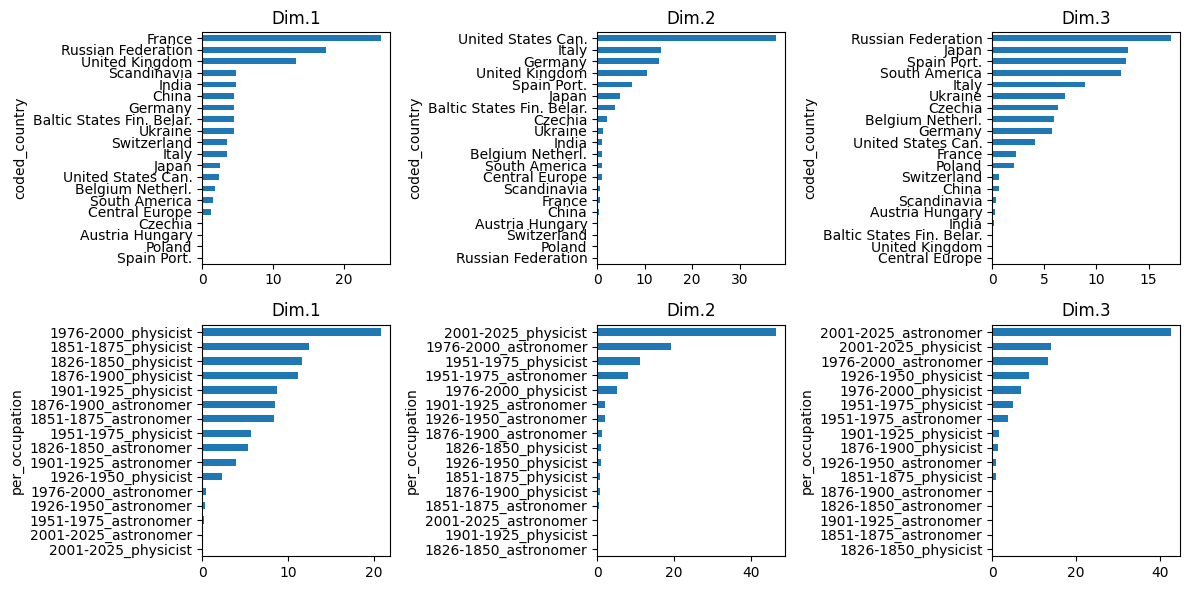

In [164]:
contributions_colonnes(afc)

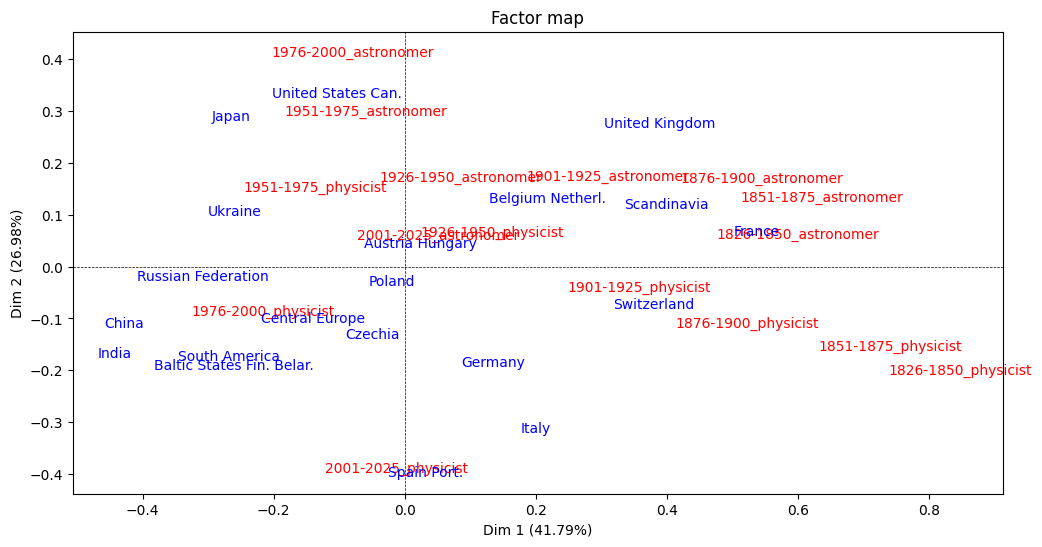

In [80]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(12,6))

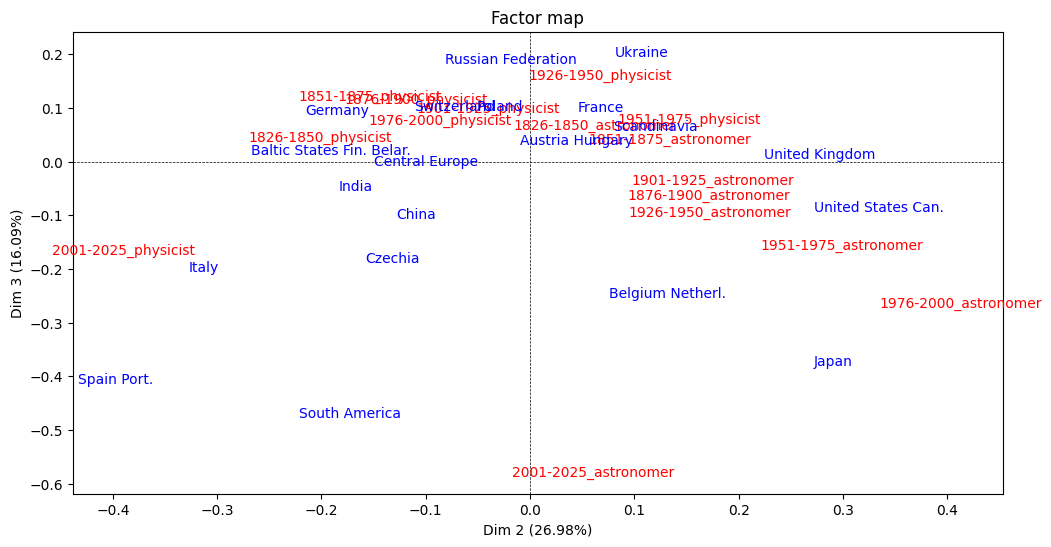

In [81]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(12,6))

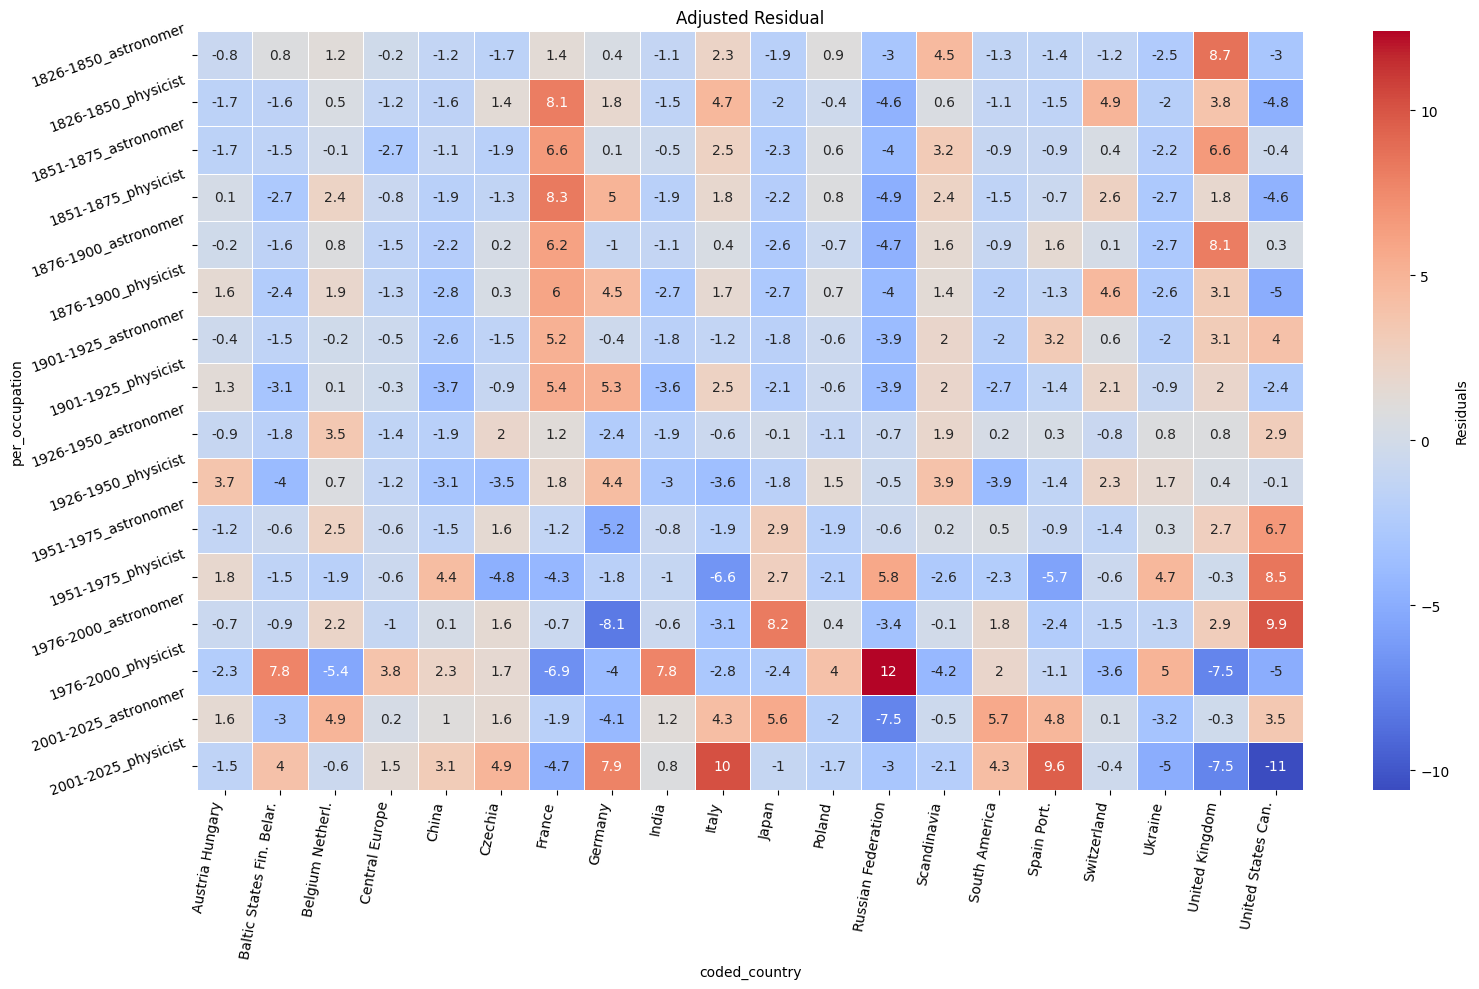

In [82]:
pp = plot_chi2_residuals(observed, figsize=(16, 10))

## Gender and main occupation vs period

In [83]:
### Apply function and create new column
df_p['occup_gen']= df_p.apply(lambda x: np.nan if pd.isna(x.occupation_main) \
                              else x.occupation_main +'_'+ code_gender(x.gender), axis=1)

In [84]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,per_gender,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,field_main,field_sec1,field_sec2,fk_person,notes,per_occupation,occup_gen
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,France,FRA,France,1831,1826-1850,1826-1850_m,27877,astronomer,mathematician,geographer,NaN,NaN,NaN,27877,NaN,1826-1850_astronomer,astronomer_m
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,Germany,DEU,Germany,1827,1826-1850,1826-1850_m,26130,astronomer,military-personnel,NaN,astronomy,NaN,NaN,26130,NaN,1826-1850_astronomer,astronomer_m


In [85]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_occGen=pd.crosstab(df_p.periodsActivity, df_p.occup_gen, margins=True)
per_vs_occGen

occup_gen,astronomer_f,astronomer_m,physicist_f,physicist_m,All
periodsActivity,,,,,
1826-1850,3,184,0,203,390
1851-1875,5,255,3,281,544
1876-1900,10,347,2,510,869
1901-1925,34,484,27,828,1373
1926-1950,62,466,105,1528,2161
1951-1975,86,653,217,3650,4606
1976-2000,95,818,331,5246,6490
2001-2025,133,479,341,2137,3090
All,428,3686,1026,14383,19523


In [86]:
observed = per_vs_occGen.iloc[:-1, :-1 ]

In [87]:
check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [88]:
expected=bivariate_stats(observed)

Chi-square : 1613.55 , dof : 21
p-value : 0.0
Inertia (Phi-square):  0.083
Cramer:  0.166


### AFC

In [89]:
afc = CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1826-...iodsActivity')
,col_labels,Index(['astro...e='occup_gen')
,stats,True


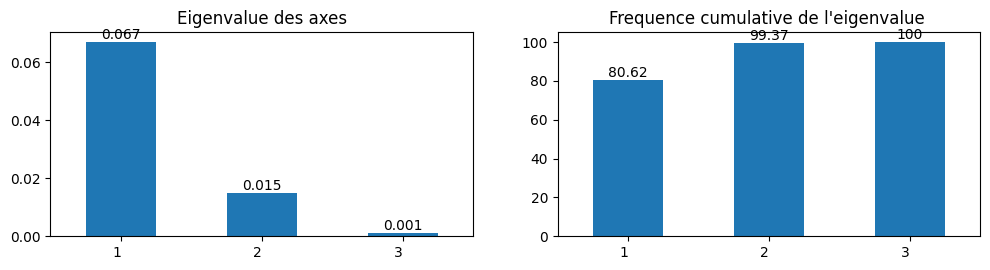

In [90]:
### Inertia (Phi-square - Eigenvalue):  0.083
print_eigenvalue(afc)

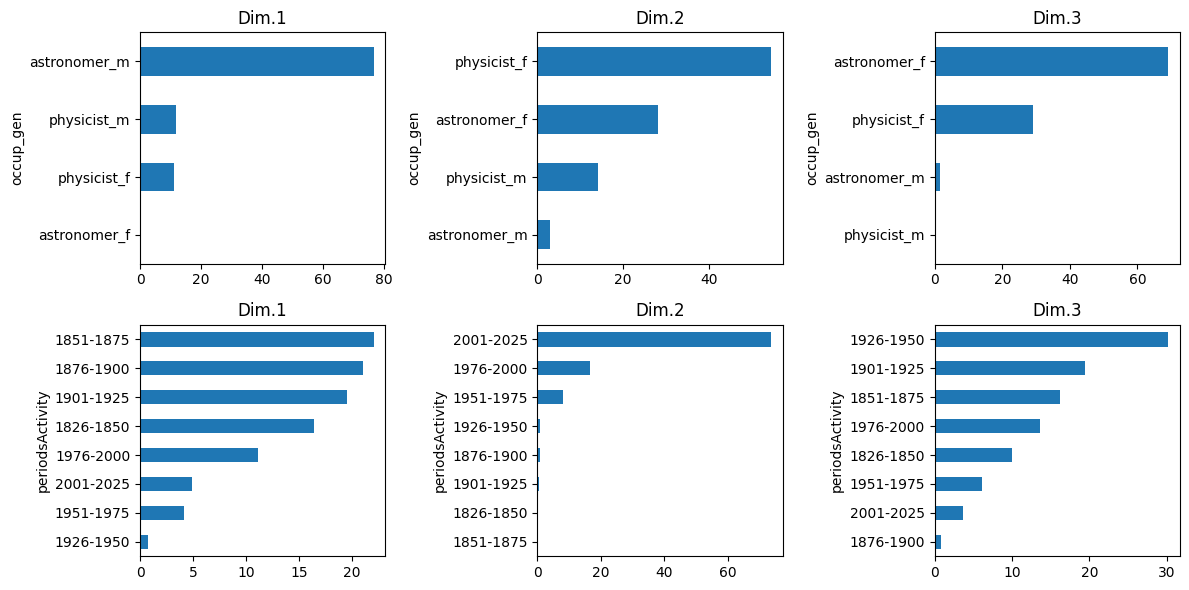

In [91]:
contributions_colonnes(afc)

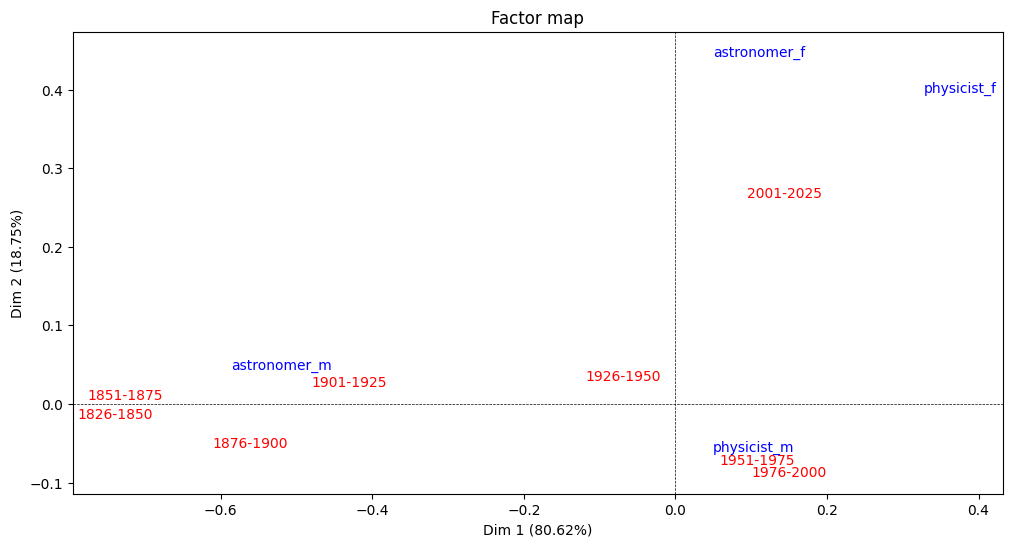

In [92]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(12,6))

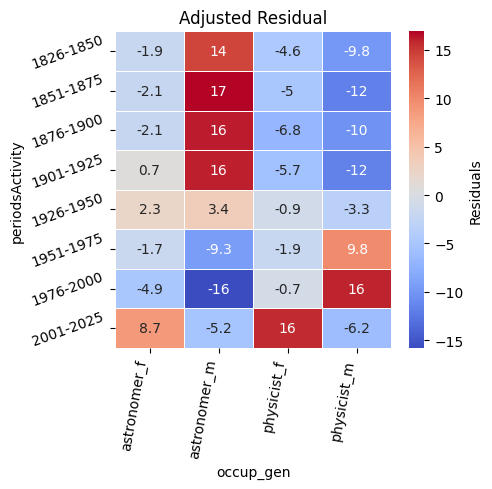

In [96]:
pp = plot_chi2_residuals(observed, figsize=(5, 5))

#### Comment
Apparently, the gender distribution follows the general evolution of disciplines and genders, with a specific interest of female scientists for physics

## Secondary occupation

In [97]:
### Inspect secondary occupations
print(df_p.groupby(by='occupation_sec1').size().sort_values(ascending=False).iloc[:50])

occupation_sec1
university-teacher          5877
mathematician                894
researcher                   532
engineer                     447
astrophysicist               377
chemist                      350
writer                       305
politician                   304
nuclear-physicist            287
scientist                    211
teacher                      176
theoretical-physicist        137
inventor                     132
professor                    131
meteorologist                121
pedagogue                     69
geophysicist                  56
academic                      55
physician                     54
philosopher                   51
computer-scientist            48
photographer                  45
translator                    41
biophysicist                  39
electrical-engineer           36
secondary-school-teacher      36
historian                     35
journalist                    34
surveyor                      32
non-fiction-writer         

In [98]:
### We define a function that codes and aggregates the values in order to avoid dispersion

def codeSecOccupation(occupation: str):
    if 'teacher' in occupation \
        or 'professor' in occupation :
        output='professor'
    elif 'pedagogue' in occupation \
        or 'academic' in occupation \
        or 'philosopher' in occupation \
        or 'translator' in occupation \
        or 'historian' in occupation:
        output='academic'
    elif 'photographer' in occupation \
        or 'journalist' in occupation \
        or 'writer' in occupation \
        or 'science-communicator' in occupation:
        output='writer_journ.'
    else:
        output=occupation
    return output                   

In [99]:
df_p['codedSecOccupation']=df_p.apply(lambda x : np.nan if pd.isna(x.occupation_sec1) \
                              else codeSecOccupation(x.occupation_sec1), axis=1)

In [123]:
### Inspect secondary occupations
dfca = df_p.groupby(by='codedSecOccupation').size().sort_values(ascending=False)

In [125]:
dfca.iloc[:14]

codedSecOccupation
professor                6239
mathematician             894
researcher                532
writer_journ.             478
engineer                  447
astrophysicist            377
chemist                   350
politician                304
academic                  295
nuclear-physicist         287
scientist                 211
theoretical-physicist     137
inventor                  132
meteorologist             121
dtype: int64

In [124]:
lc=dfca.iloc[:14].index.to_list()
lc

['professor',
 'mathematician',
 'researcher',
 'writer_journ.',
 'engineer',
 'astrophysicist',
 'chemist',
 'politician',
 'academic',
 'nuclear-physicist',
 'scientist',
 'theoretical-physicist',
 'inventor',
 'meteorologist']

## Secondary occupation vs country

In [103]:
### Contingency table: 
dfc = df_p[df_p.codedSecOccupation.isin(lc)]
occ_vs_country=pd.crosstab(dfc.coded_country, dfc.codedSecOccupation, margins=True)
occ_vs_country

codedSecOccupation,academic,astrophysicist,chemist,engineer,inventor,mathematician,meteorologist,nuclear-physicist,politician,professor,researcher,scientist,theoretical-physicist,writer_journ.,All
coded_country,,,,,,,,,,,,,,,
Austria Hungary,12,8,20,17,7,40,7,17,13,301,10,3,4,27,486
Baltic States Fin. Belar.,11,14,6,8,8,19,6,3,35,143,21,25,5,17,321
Belgium Netherl.,2,5,10,7,3,14,3,1,6,254,13,1,6,11,336
Central Europe,15,9,15,17,4,52,6,9,18,179,25,2,5,22,378
China,3,8,3,8,4,10,1,19,14,55,13,0,2,4,144
Czechia,39,15,20,8,1,68,6,4,17,390,17,17,3,45,650
France,22,34,46,57,9,72,10,2,13,263,100,4,1,27,660
Germany,39,40,54,34,15,117,16,36,32,1525,42,7,6,75,2038
India,2,17,4,12,0,10,2,18,3,75,4,2,6,10,165


In [104]:
observed = occ_vs_country.iloc[:-1, :-1 ]

In [105]:
check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [106]:
expected=bivariate_stats(observed)

Chi-square : 2117.32 , dof : 247
p-value : 0.0
Inertia (Phi-square):  0.196
Cramer:  0.123


### AFC

In [107]:
afc = CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['Austr...oded_country')
,col_labels,Index(['acade...ecOccupation')
,stats,True


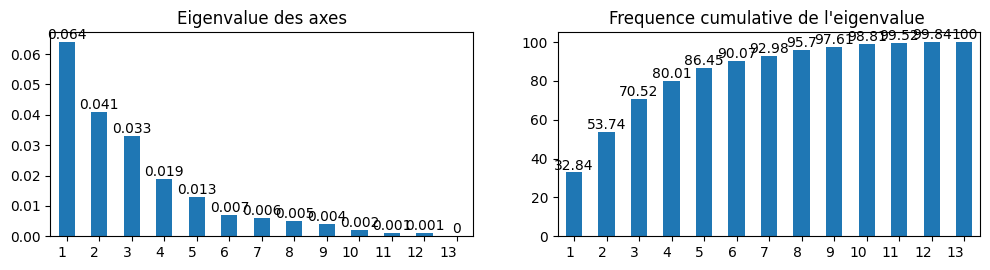

In [108]:
### Inertia (Phi-square - Eigenvalue):  0.083
print_eigenvalue(afc)

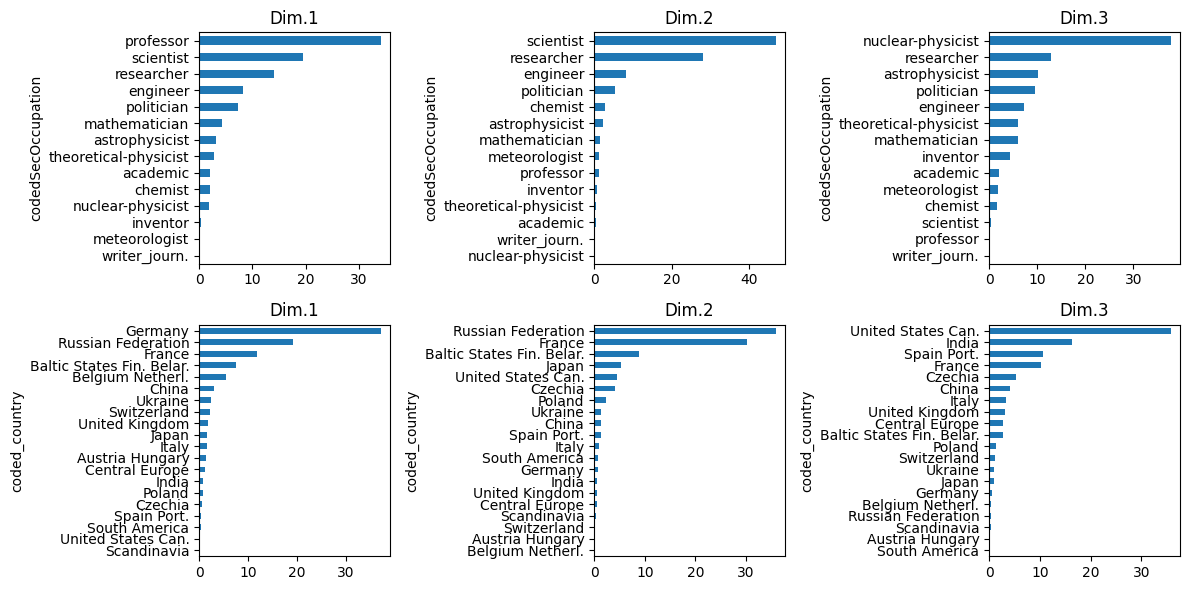

In [109]:
contributions_colonnes(afc)

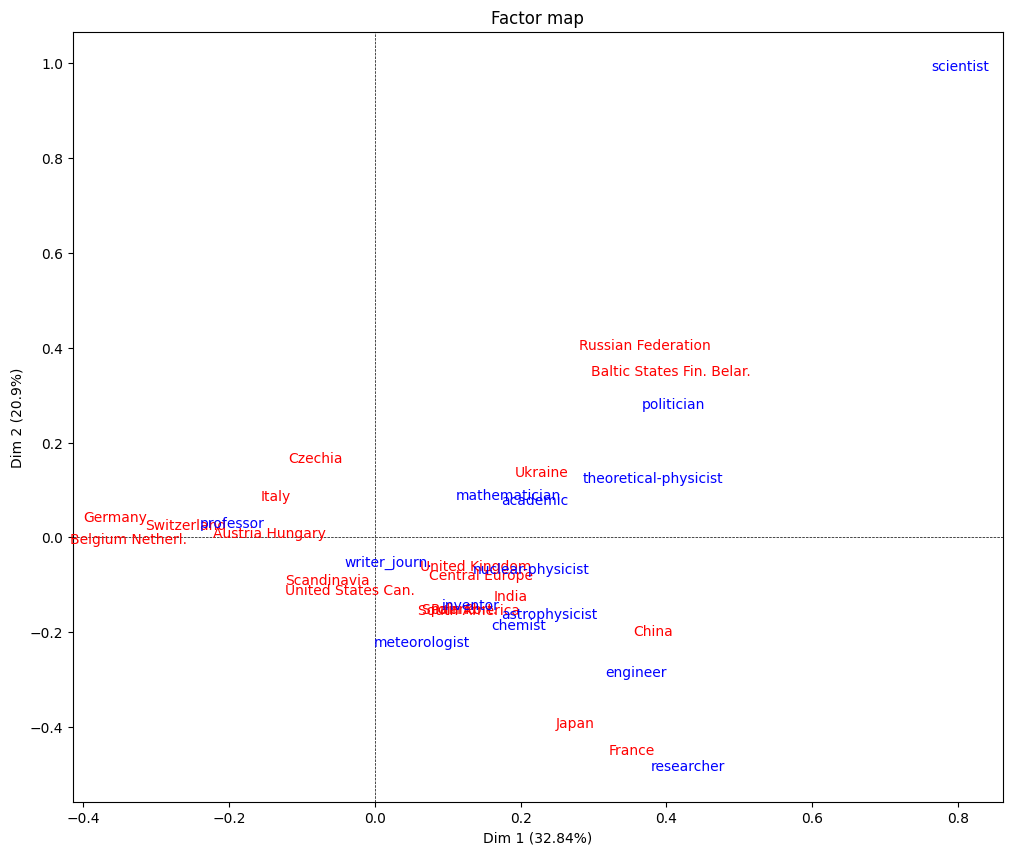

In [110]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(12,10))

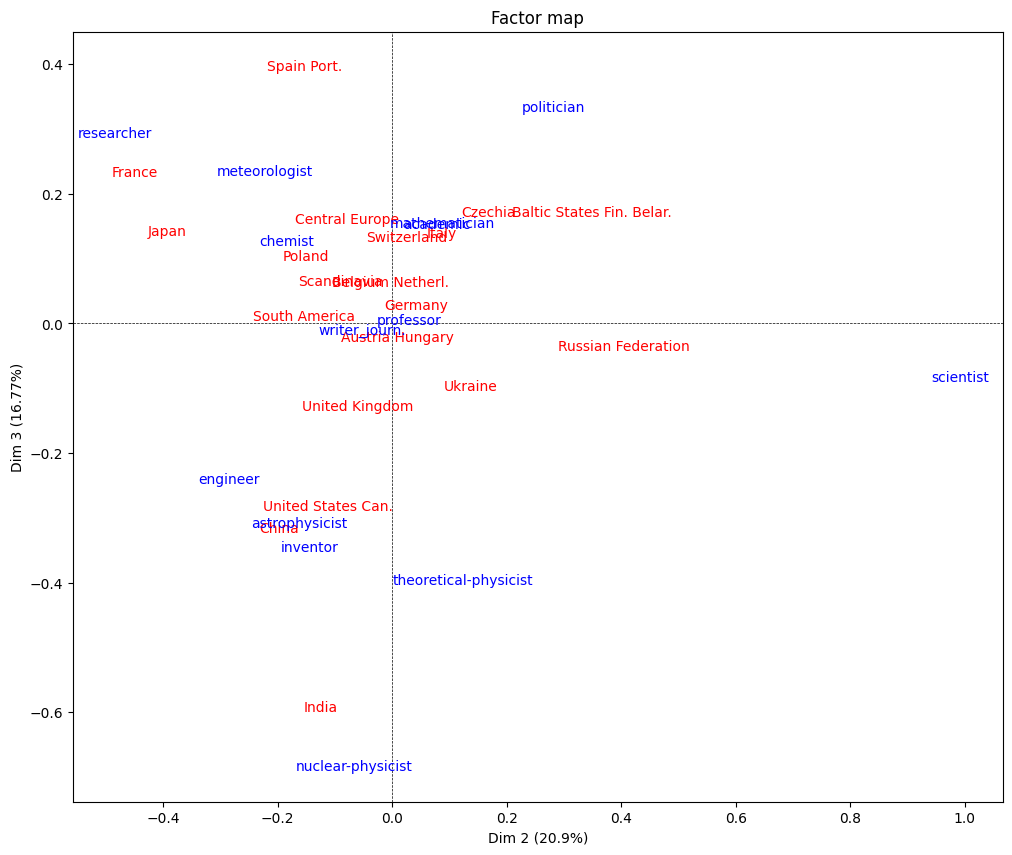

In [111]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(12,10))

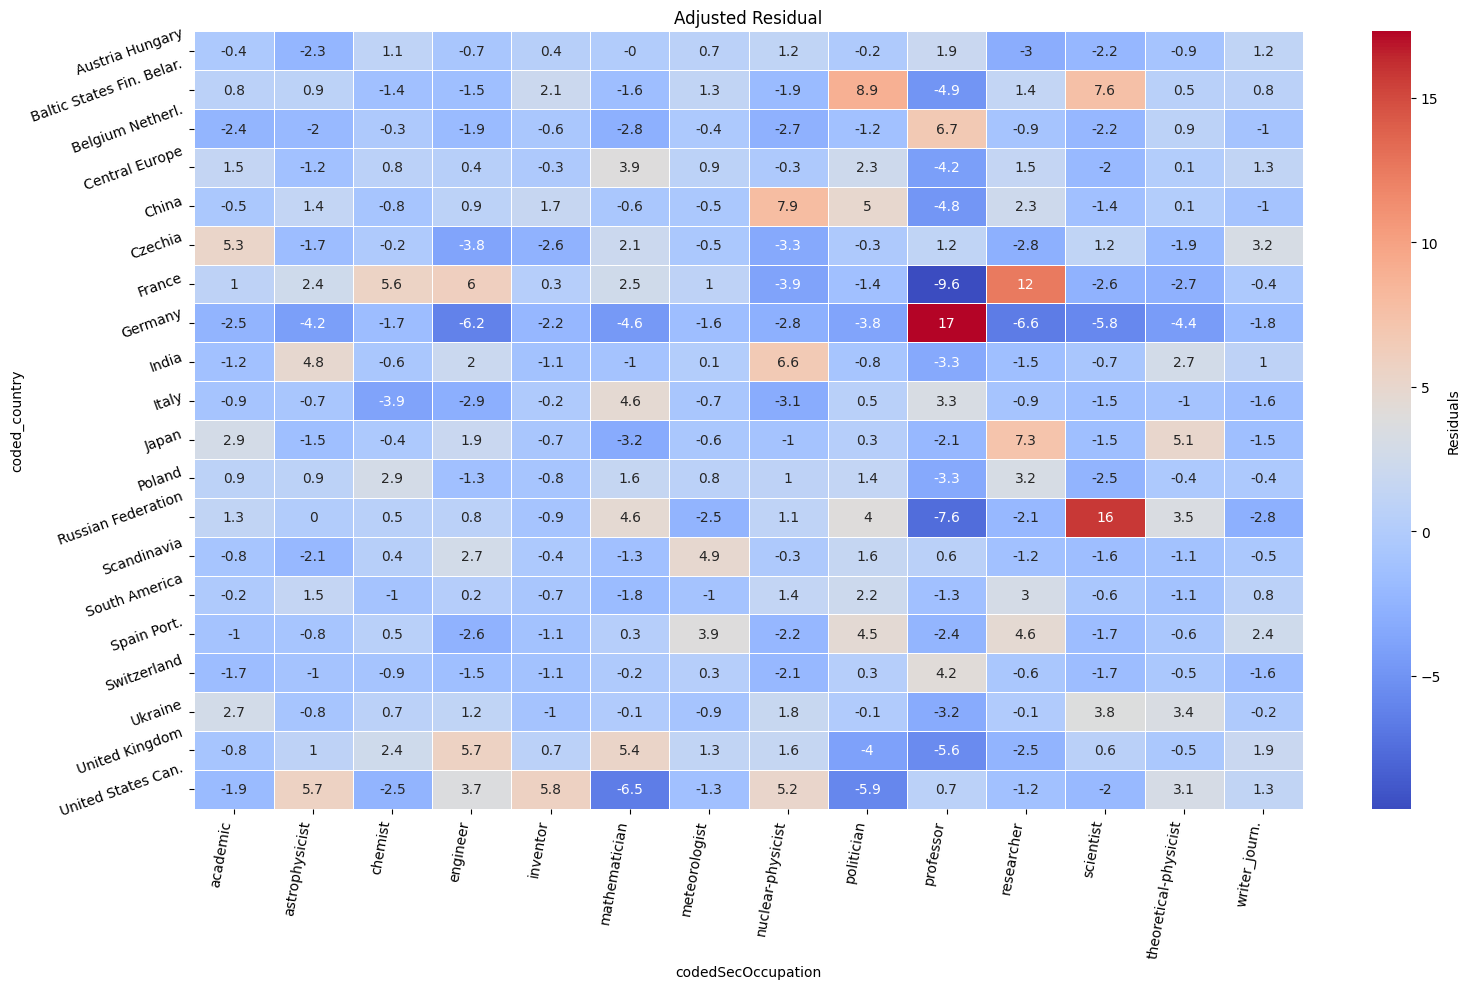

In [223]:
pp = plot_chi2_residuals(observed, figsize=(16, 10))

## Secondary occupation vs period

In [112]:
### Contingency table: 
dfc = df_p[df_p.codedSecOccupation.isin(lc)]
occ_vs_per=pd.crosstab(dfc.periodsActivity, dfc.codedSecOccupation, margins=True)
occ_vs_per

codedSecOccupation,academic,astrophysicist,chemist,engineer,inventor,mathematician,meteorologist,nuclear-physicist,politician,professor,researcher,scientist,theoretical-physicist,writer_journ.,All
periodsActivity,,,,,,,,,,,,,,,
1826-1850,3,0,17,8,7,74,5,0,10,113,0,1,0,12,250
1851-1875,10,6,27,23,9,85,7,0,17,164,1,4,0,26,379
1876-1900,19,10,37,32,9,115,25,0,15,311,2,5,0,26,606
1901-1925,24,13,44,54,23,122,19,2,23,472,5,5,3,36,845
1926-1950,33,33,68,80,17,128,21,31,25,731,8,19,7,55,1256
1951-1975,67,57,74,130,35,157,20,154,42,1510,42,56,36,64,2444
1976-2000,102,160,65,86,28,149,14,87,117,2024,203,86,68,159,3348
2001-2025,37,98,18,34,4,64,10,13,55,914,271,35,23,100,1676
All,295,377,350,447,132,894,121,287,304,6239,532,211,137,478,10804


In [113]:
observed = occ_vs_per.iloc[:-1, :-1 ]

In [114]:
check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [115]:
expected=bivariate_stats(observed)

Chi-square : 1862.64 , dof : 91
p-value : 0.0
Inertia (Phi-square):  0.172
Cramer:  0.157


### AFC

In [116]:
afc = CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1826-...iodsActivity')
,col_labels,Index(['acade...ecOccupation')
,stats,True


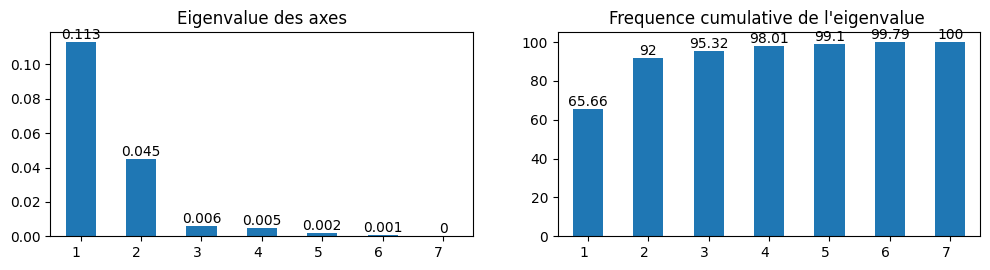

In [117]:
### Inertia (Phi-square - Eigenvalue):  0.083
print_eigenvalue(afc)

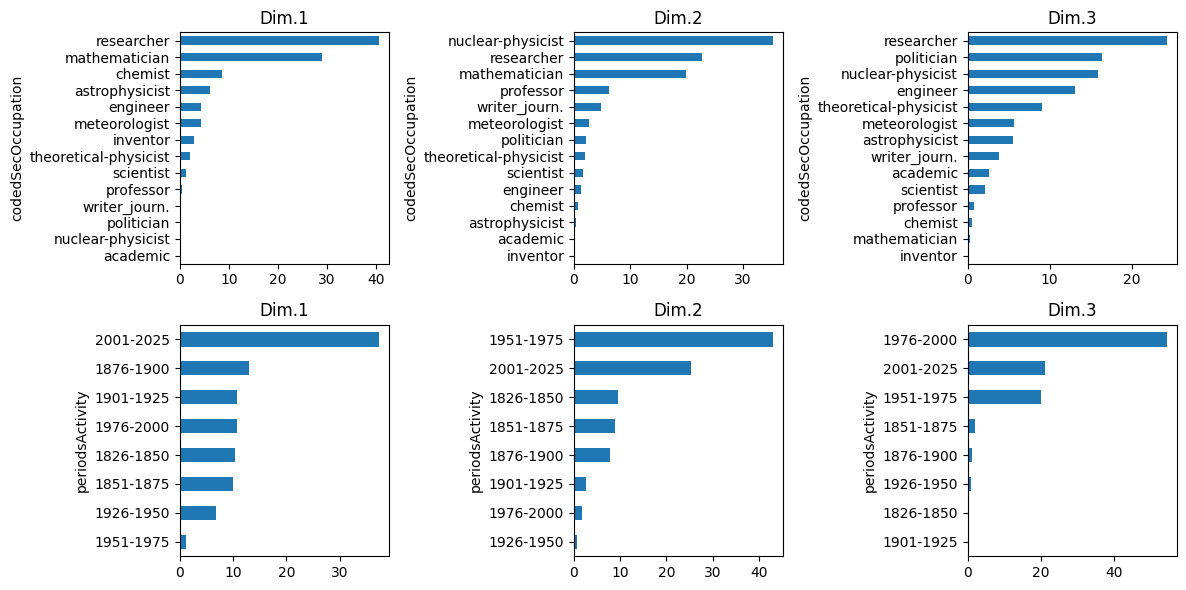

In [118]:
contributions_colonnes(afc)

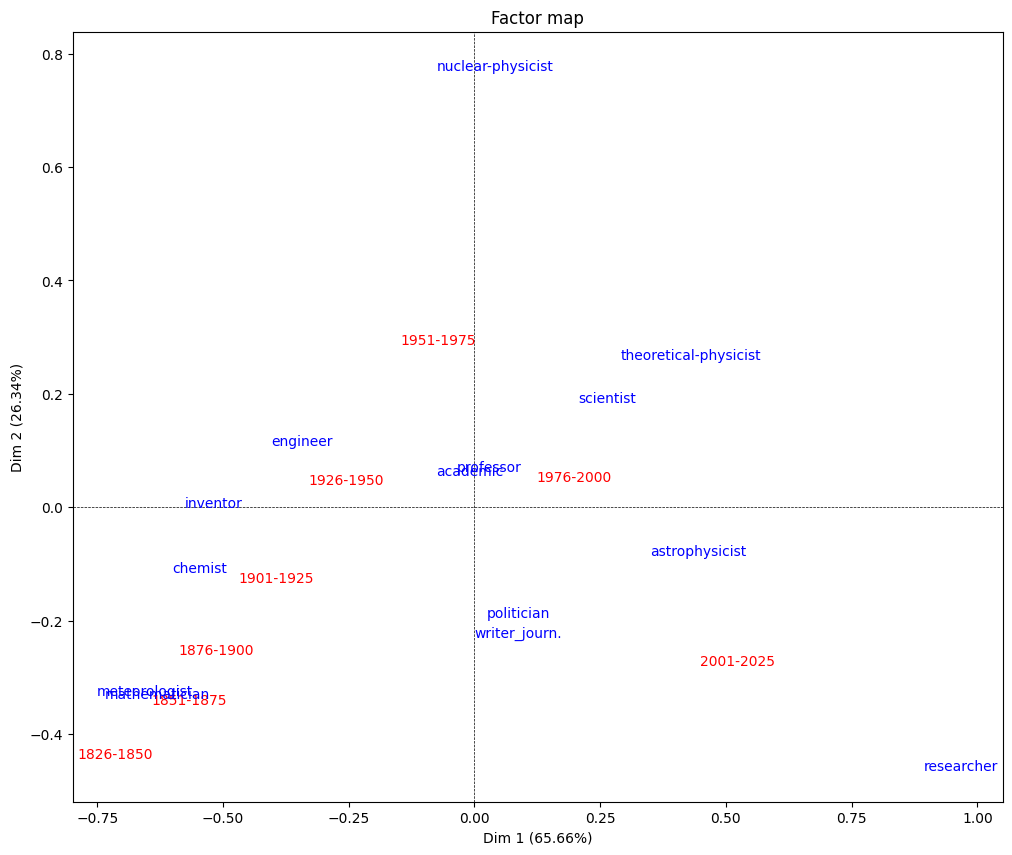

In [119]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(12,10))

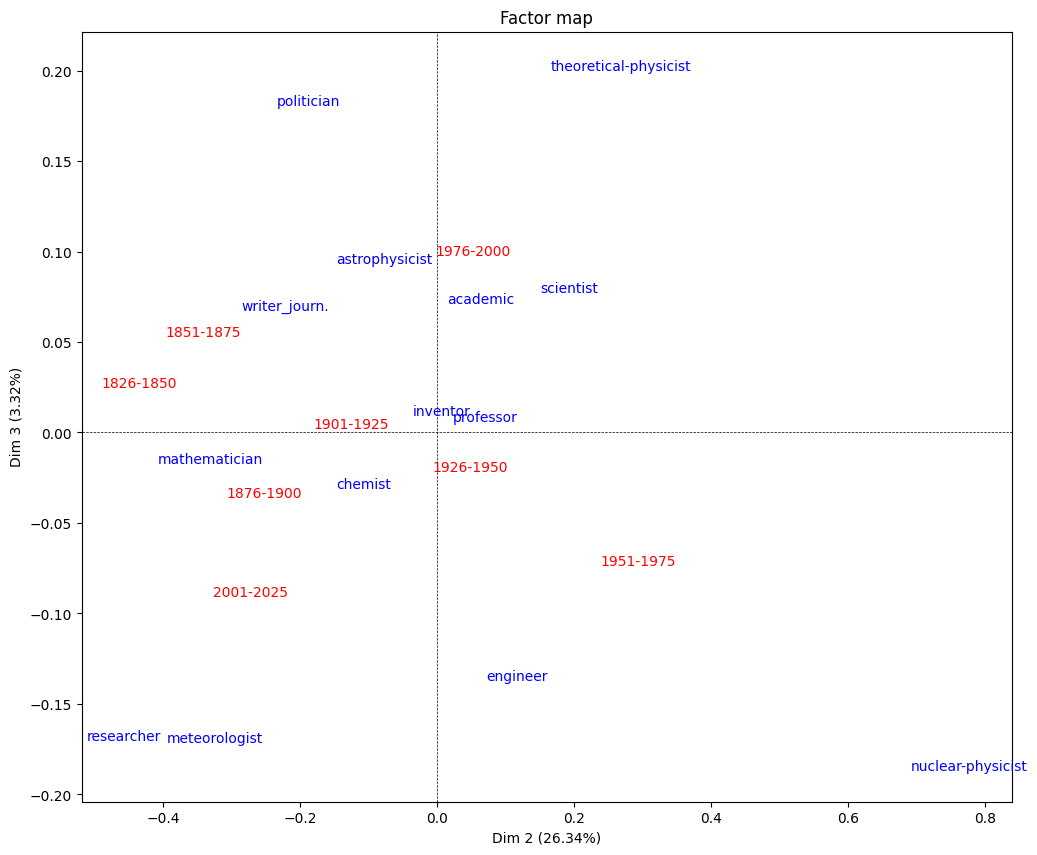

In [120]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(12,10))

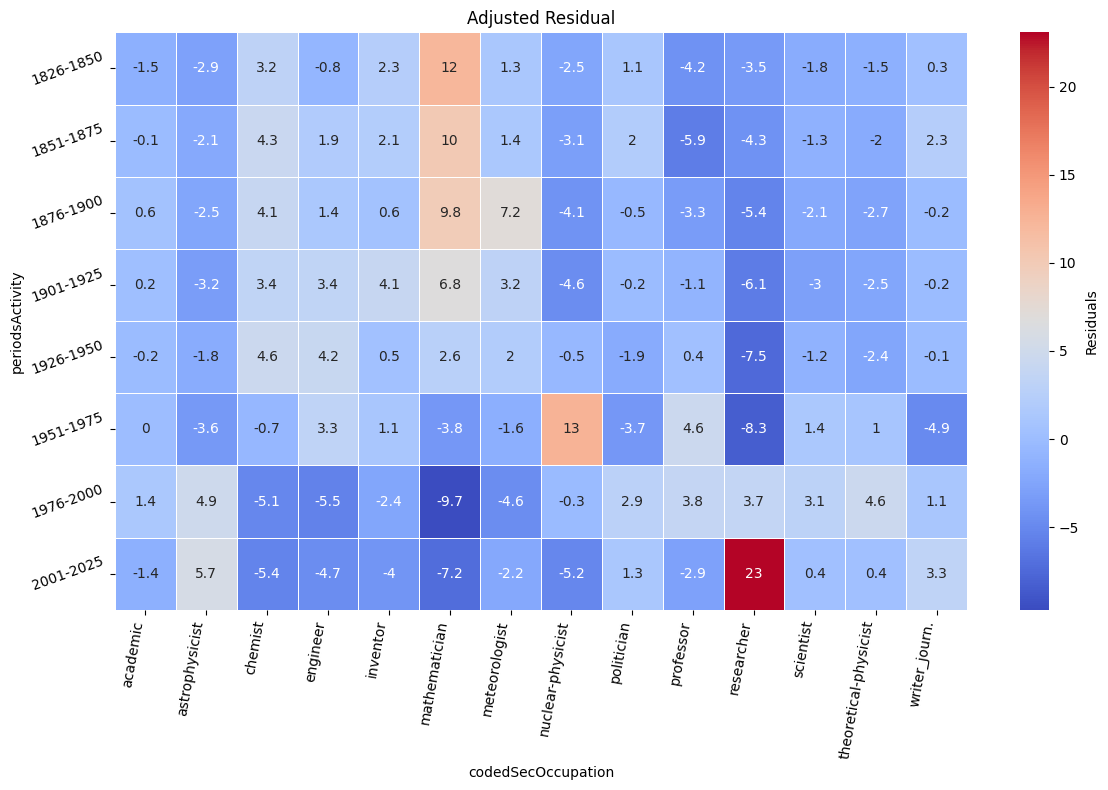

In [121]:
pp = plot_chi2_residuals(observed, figsize=(12,8))

## Secondary occupation (more categories) vs period

In [142]:
dfca.iloc[11:50]

codedSecOccupation
theoretical-physicist       137
inventor                    132
meteorologist               121
geophysicist                 56
physician                    54
computer-scientist           48
biophysicist                 39
electrical-engineer          36
surveyor                     32
geologist                    26
discoverer-of-asteroids      24
author                       23
catholic-priest              21
biologist                    21
astronaut                    20
businessperson               19
poet                         19
painter                      17
crystallographer             16
explorer                     16
naturalist                   16
geographer                   16
thermophysicist              15
botanist                     15
lecturer                     14
composer                     14
military-personnel           14
entrepreneur                 14
mechanical-engineer          13
military-flight-engineer     13
manager              

In [143]:
lc=dfca.iloc[11:50].index.to_list()
lc

['theoretical-physicist',
 'inventor',
 'meteorologist',
 'geophysicist',
 'physician',
 'computer-scientist',
 'biophysicist',
 'electrical-engineer',
 'surveyor',
 'geologist',
 'discoverer-of-asteroids',
 'author',
 'catholic-priest',
 'biologist',
 'astronaut',
 'businessperson',
 'poet',
 'painter',
 'crystallographer',
 'explorer',
 'naturalist',
 'geographer',
 'thermophysicist',
 'botanist',
 'lecturer',
 'composer',
 'military-personnel',
 'entrepreneur',
 'mechanical-engineer',
 'military-flight-engineer',
 'manager',
 'cartographer',
 'metallurgist',
 'esperantist',
 'docent',
 'civil-engineer',
 'economist',
 'materials-scientist',
 'mountaineer']

In [144]:
### Contingency table: 
dfc = df_p[df_p.codedSecOccupation.isin(lc)]
occ_vs_per=pd.crosstab(dfc.periodsActivity, dfc.codedSecOccupation, margins=True)
occ_vs_per

codedSecOccupation,astronaut,author,biologist,biophysicist,botanist,businessperson,cartographer,catholic-priest,civil-engineer,composer,computer-scientist,crystallographer,discoverer-of-asteroids,docent,economist,electrical-engineer,entrepreneur,esperantist,explorer,geographer,geologist,geophysicist,inventor,lecturer,manager,materials-scientist,mechanical-engineer,metallurgist,meteorologist,military-flight-engineer,military-personnel,mountaineer,naturalist,painter,physician,poet,surveyor,theoretical-physicist,thermophysicist,All
periodsActivity,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1826-1850,0,0,0,0,4,2,1,2,0,0,0,0,1,0,1,0,0,0,1,1,3,0,7,1,0,0,0,0,5,0,2,0,2,1,10,1,3,0,0,48
1851-1875,0,0,1,0,2,0,1,1,2,2,0,1,3,0,0,1,0,0,1,3,2,1,9,0,0,0,0,0,7,0,1,0,3,1,11,0,3,0,0,56
1876-1900,0,1,0,0,2,1,1,3,1,1,0,0,2,0,0,1,0,1,3,2,4,3,9,0,0,0,0,1,25,0,4,1,5,0,8,3,4,0,0,86
1901-1925,0,1,2,1,3,2,6,4,3,2,1,1,1,0,0,3,3,2,4,3,1,5,23,1,0,0,1,0,19,1,2,0,3,4,10,0,10,3,0,125
1926-1950,0,3,3,4,2,1,0,5,0,0,0,3,7,0,0,8,0,1,3,3,5,18,17,0,0,0,1,6,21,3,1,2,1,3,5,1,6,7,4,144
1951-1975,2,3,7,11,0,2,1,3,1,1,8,10,2,7,1,11,3,3,4,3,5,10,35,3,3,2,5,1,20,7,3,2,1,4,4,1,6,36,6,237
1976-2000,10,6,6,16,1,6,0,3,2,4,21,1,6,3,6,9,5,2,0,1,3,11,28,7,5,6,4,2,14,2,1,3,1,3,5,10,0,68,4,285
2001-2025,8,9,2,7,1,5,1,0,1,4,18,0,2,0,2,3,3,1,0,0,3,8,4,2,3,2,2,0,10,0,0,1,0,1,1,3,0,23,1,131
All,20,23,21,39,15,19,11,21,10,14,48,16,24,10,10,36,14,10,16,16,26,56,132,14,11,10,13,10,121,13,14,9,16,17,54,19,32,137,15,1112


In [145]:
observed = occ_vs_per.iloc[:-1, :-1 ]

In [146]:
check_chi_square_test_validity(observed)

Table valid for Chi-square test: False


### AFC

In [147]:
afc = CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,Index(['1826-...iodsActivity')
,col_labels,Index(['astro...ecOccupation')
,stats,True


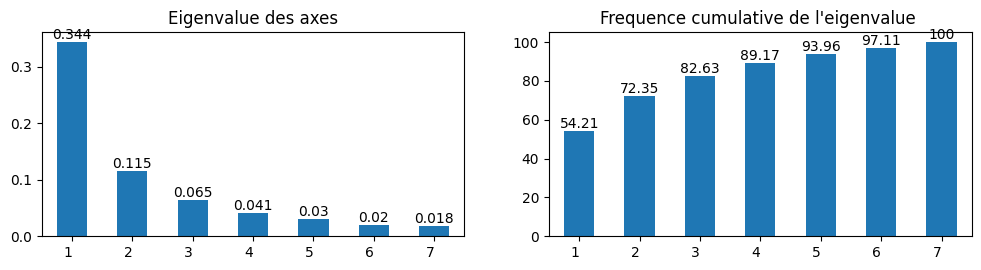

In [148]:
### Inertia (Phi-square - Eigenvalue):  0.083
print_eigenvalue(afc)

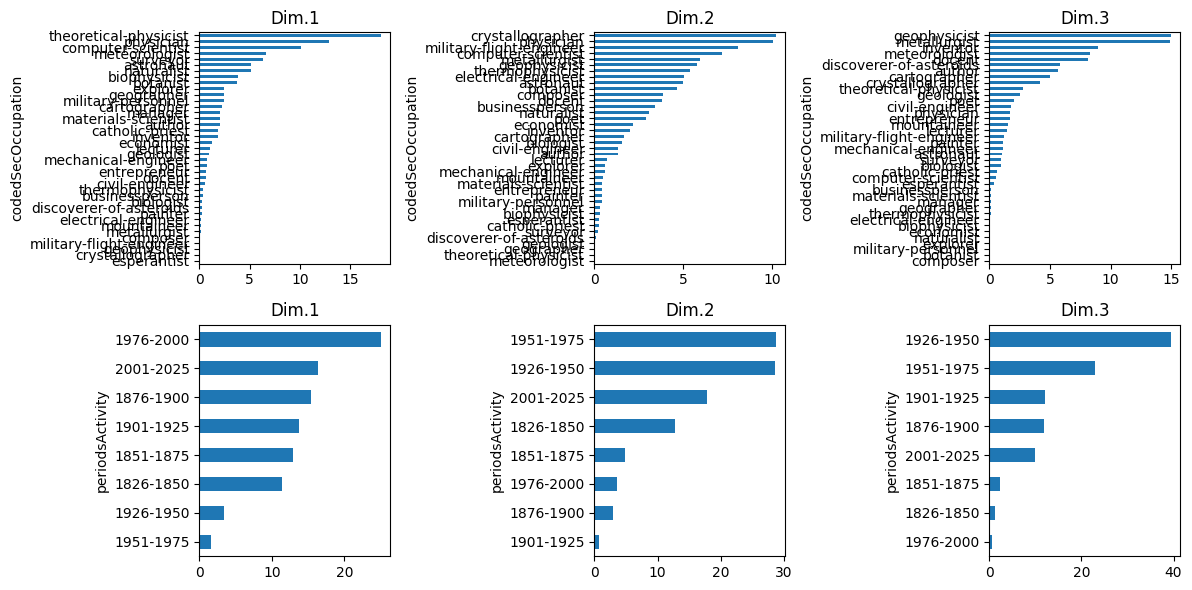

In [149]:
contributions_colonnes(afc)

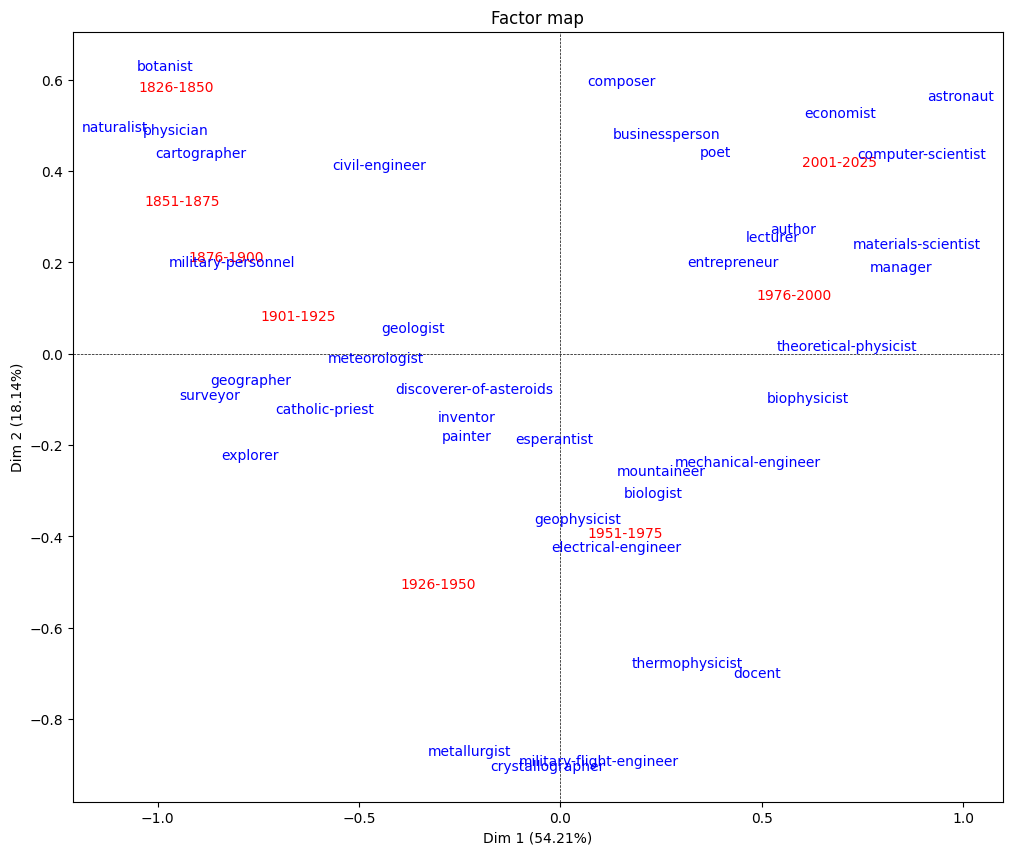

In [152]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(12,10))

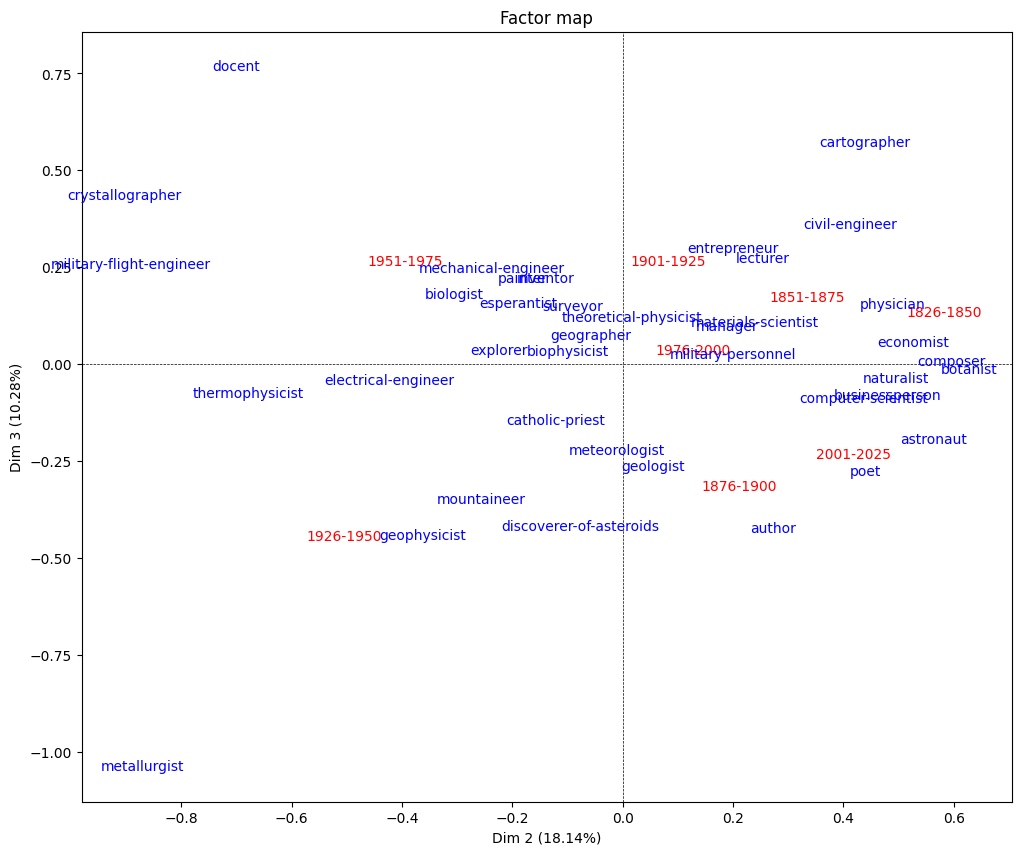

In [153]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(12,10))

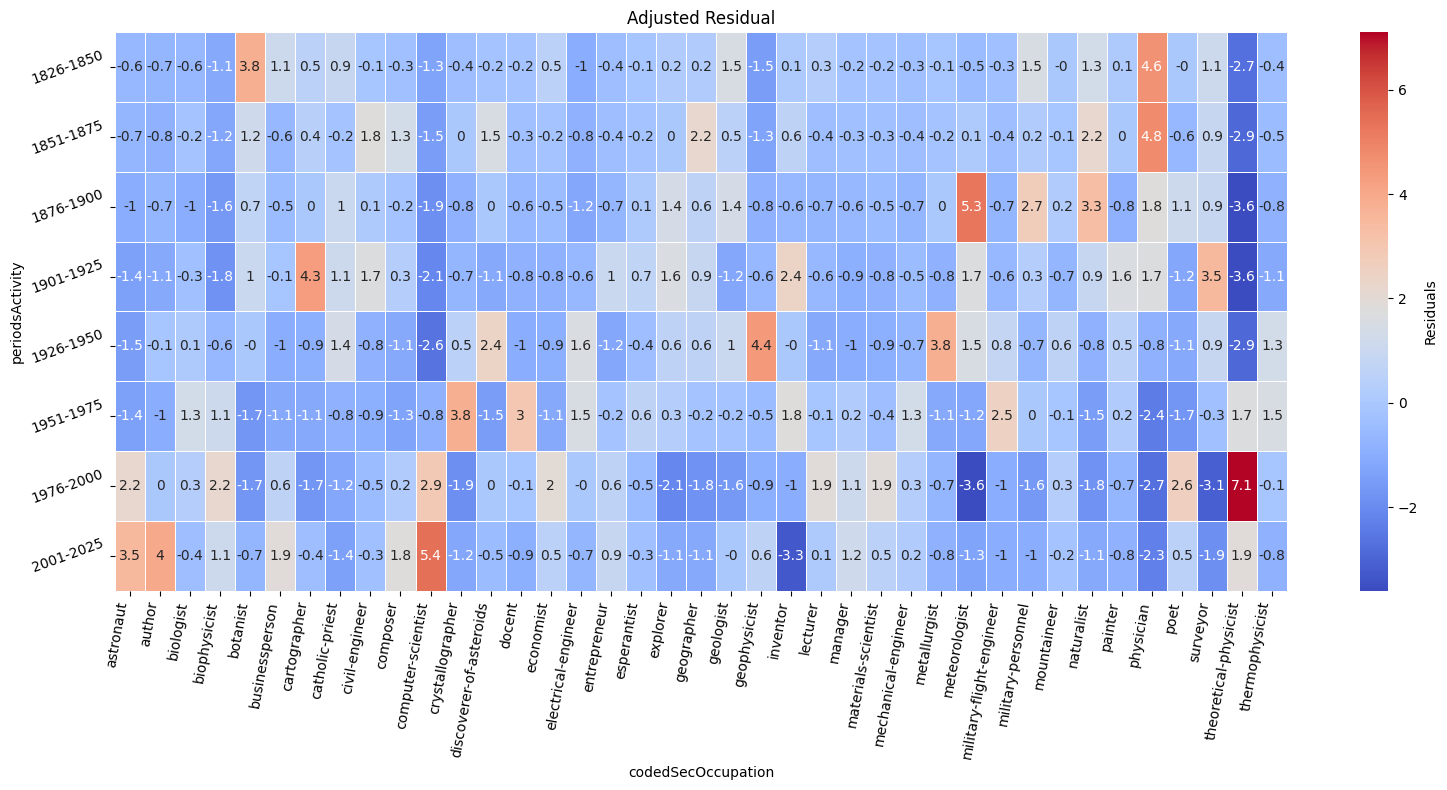

In [156]:
pp = plot_chi2_residuals(observed, figsize=(16,8))